# Machine Learning Algorithms on Financial Market Data
### EUR/USD and S&P 500 — 34 forecasting algorithms, explained, applied and evaluated

This notebook is a complete data science workflow on two very different financial markets:

| Market | Type | Characteristics |
|---|---|---|
| **EUR/USD** | Currency pair (FX) | most traded currency pair in the world, no long-term drift, long up and down cycles |
| **S&P 500** | US equity index (500 companies) | long-term upward trend, sharp crashes, strong reaction to economic news |

Every step is explained: the data, the preparation, how each algorithm works and what it is designed for (with
its original source), how it is evaluated, and what its results mean.

| Part | Content |
|---|---|
| 1 | Setup |
| 2 | Data collection |
| 3 | Data cleaning |
| 4 | Exploratory data analysis |
| 5 | Feature engineering |
| 6 | Train / validation / test split |
| 7 | Evaluation metrics (with sources) |
| 8 | The 34 algorithms: objective, how they work, sources |
| 9 | Training and evaluation |
| 10 | Results: EUR/USD |
| 11 | Results: S&P 500 |
| 12 | EUR/USD vs S&P 500 comparison |
| 13 | Summary |

**Forecasting task.** For each market, predict the **next day's closing price** from the information available at
today's close. This is the standard one-step-ahead time-series forecasting problem.

## 1. Setup

In [1]:
import time, warnings, logging, inspect, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import torch, torch.nn as nn
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, TiDE, DLinear, DeepAR, PatchTST, TFT, TCN, BiTCN
from neuralforecast.losses.pytorch import MAE as NF_MAE, DistributionLoss
import h2o
from h2o.automl import H2OAutoML

warnings.filterwarnings("ignore")
for n in ["lightgbm", "pytorch_lightning", "lightning", "lightning.pytorch", "lightning_fabric", "neuralforecast"]:
    logging.getLogger(n).setLevel(logging.ERROR)
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

MARKETS = {
    "EUR/USD": {"mt5": "EURUSD", "yahoo": "EURUSD=X", "start": "2005-01-01", "unit": 0.0001, "unit_name": "pips"},
    "S&P 500": {"mt5": "US500",  "yahoo": "^GSPC",    "start": "2005-01-01", "unit": 1.0,    "unit_name": "points", "source": "yahoo"},
}
DATA_SOURCE = "auto"
TRAIN_END, VALID_END = "2019-12-31", "2022-12-31"
H2O_BUDGET = 120
DATA_DIR = Path("data"); (DATA_DIR / "cache").mkdir(parents=True, exist_ok=True)

FAM_COL = {"Baseline": "#898781", "Statistical": "#2a78d6", "Linear": "#eb6834", "Distance / kernel": "#e87ba4",
           "Trees": "#1baf7a", "Boosting": "#eda100", "Neural networks": "#4a3aa7", "Deep forecasting": "#008300",
           "AutoML": "#e34948", "Ensembles": "#0d366b"}
MK_COL = {"EUR/USD": "#2a78d6", "S&P 500": "#1baf7a"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (12, 4.5), "figure.dpi": 110, "axes.facecolor": "#fcfcfb", "figure.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "lines.linewidth": 1.5, "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "axes.titleweight": "bold", "axes.titlesize": 11, "legend.frameon": False})

## 2. Data collection
Daily OHLC bars (open, high, low, close) are loaded for both markets from 2005 onwards.
* **EUR/USD**: from the **MetaTrader 5** terminal (Python API), with Yahoo Finance and CSV as fallbacks.
* **S&P 500**: from **Yahoo Finance** (index `^GSPC`), because the broker history in MetaTrader 5 only starts in
  2012. Using Yahoo Finance gives both markets the same history length (2005 to 2026). Each downloaded series is
saved to `data/` so that every run uses the same snapshot.

In [2]:
def from_mt5(sym):
    import MetaTrader5 as mt5
    if not mt5.initialize(): raise RuntimeError(mt5.last_error())
    try:
        mt5.symbol_select(sym, True)
        r = mt5.copy_rates_from_pos(sym, mt5.TIMEFRAME_D1, 0, mt5.terminal_info().maxbars - 1)
        if r is None or len(r) == 0: raise RuntimeError("no data")
    finally:
        mt5.shutdown()
    d = pd.DataFrame(r); d.index = pd.to_datetime(d["time"], unit="s")
    return d[["open", "high", "low", "close"]].iloc[:-1]

def from_yahoo(tk, start):
    import yfinance as yf
    d = yf.download(tk, start=start, interval="1d", auto_adjust=False, progress=False)
    if isinstance(d.columns, pd.MultiIndex): d.columns = d.columns.get_level_values(0)
    d.columns = [c.lower() for c in d.columns]
    return d[["open", "high", "low", "close"]]

RAW, SOURCE = {}, {}
for name, spec in MARKETS.items():
    csv = DATA_DIR / f"{spec['mt5']}_D1.csv"
    order = {"auto": ["mt5", "yahoo", "csv"], "mt5": ["mt5"], "yahoo": ["yahoo"], "csv": ["csv"]}[spec.get("source", DATA_SOURCE)]
    for src in order:
        try:
            d = {"mt5": lambda: from_mt5(spec["mt5"]), "yahoo": lambda: from_yahoo(spec["yahoo"], spec["start"]),
                 "csv": lambda: pd.read_csv(csv, index_col=0, parse_dates=True)}[src]()
            if src != "csv": d.to_csv(csv)
            RAW[name], SOURCE[name] = d.loc[spec["start"]:], src; break
        except Exception as e:
            print(f"{name}: {src} unavailable ({e})")
    print(f"{name}: source = {SOURCE[name]} | {len(RAW[name]):,} daily bars from {RAW[name].index[0].date()} to {RAW[name].index[-1].date()}")

EUR/USD: source = mt5 | 5,646 daily bars from 2005-01-03 to 2026-10-02


S&P 500: source = yahoo | 5,472 daily bars from 2005-01-03 to 2026-10-02


## 3. Data cleaning
Before modelling, each dataset is checked for missing values, duplicated dates, impossible prices (non-positive
prices, high below low, close outside the high-low range), rows on non-trading days, calendar gaps and extreme moves.
Invalid rows are removed. Extreme moves are kept, because they are real market events.

In [3]:
def clean(raw):
    d = raw.copy(); d.index = pd.to_datetime(d.index).normalize()
    rep = {"rows": len(d), "missing values": int(d.isna().sum().sum()), "duplicated dates": int(d.index.duplicated().sum()),
           "non-positive prices": int((d <= 0).any(axis=1).sum()), "high < low": int((d.high < d.low).sum()),
           "close outside [low, high]": int(((d.close > d.high) | (d.close < d.low)).sum()),
           "weekend rows": int((d.index.dayofweek >= 5).sum()), "gaps > 4 days": int((d.index.to_series().diff().dt.days > 4).sum())}
    d = d[~d.index.duplicated(keep="last")].dropna()
    d = d[(d > 0).all(axis=1) & (d.high >= d.low) & (d.index.dayofweek < 5)]
    c = d.close.pct_change(); z = (c - c.median()) / (1.4826 * (c - c.median()).abs().median())
    rep["extreme moves (|robust z| > 8)"] = int((z.abs() > 8).sum()); rep["rows after cleaning"] = len(d)
    return d, rep
DF, QC = {}, {}
for name in MARKETS: DF[name], QC[name] = clean(RAW[name])
display(pd.DataFrame(QC))

,EUR/USD,S&P 500
rows,5646,5472
missing values,0,0
duplicated dates,0,0
non-positive prices,0,0
high < low,0,0
"close outside [low, high]",0,0
weekend rows,0,0
gaps > 4 days,0,2
extreme moves (|robust z| > 8),0,26
rows after cleaning,5646,5472


**Result.** Both datasets pass every validity check: no missing values, no duplicated dates, no invalid prices and no
weekend rows. No row has to be removed.
* **EUR/USD** (MetaTrader 5): 5 646 daily bars, 2005 to 2026, with no extreme move by the robust-z criterion.
* **S&P 500** (Yahoo Finance): 5 472 daily bars, 2005 to 2026. There are 2 gaps longer than 4 days (exceptional
  exchange closures) and 26 extreme moves, which are the large daily moves of the 2008 financial crisis and of
  March 2020. These are real events and are kept.

## 4. Exploratory data analysis
### 4.1 Price history and daily changes

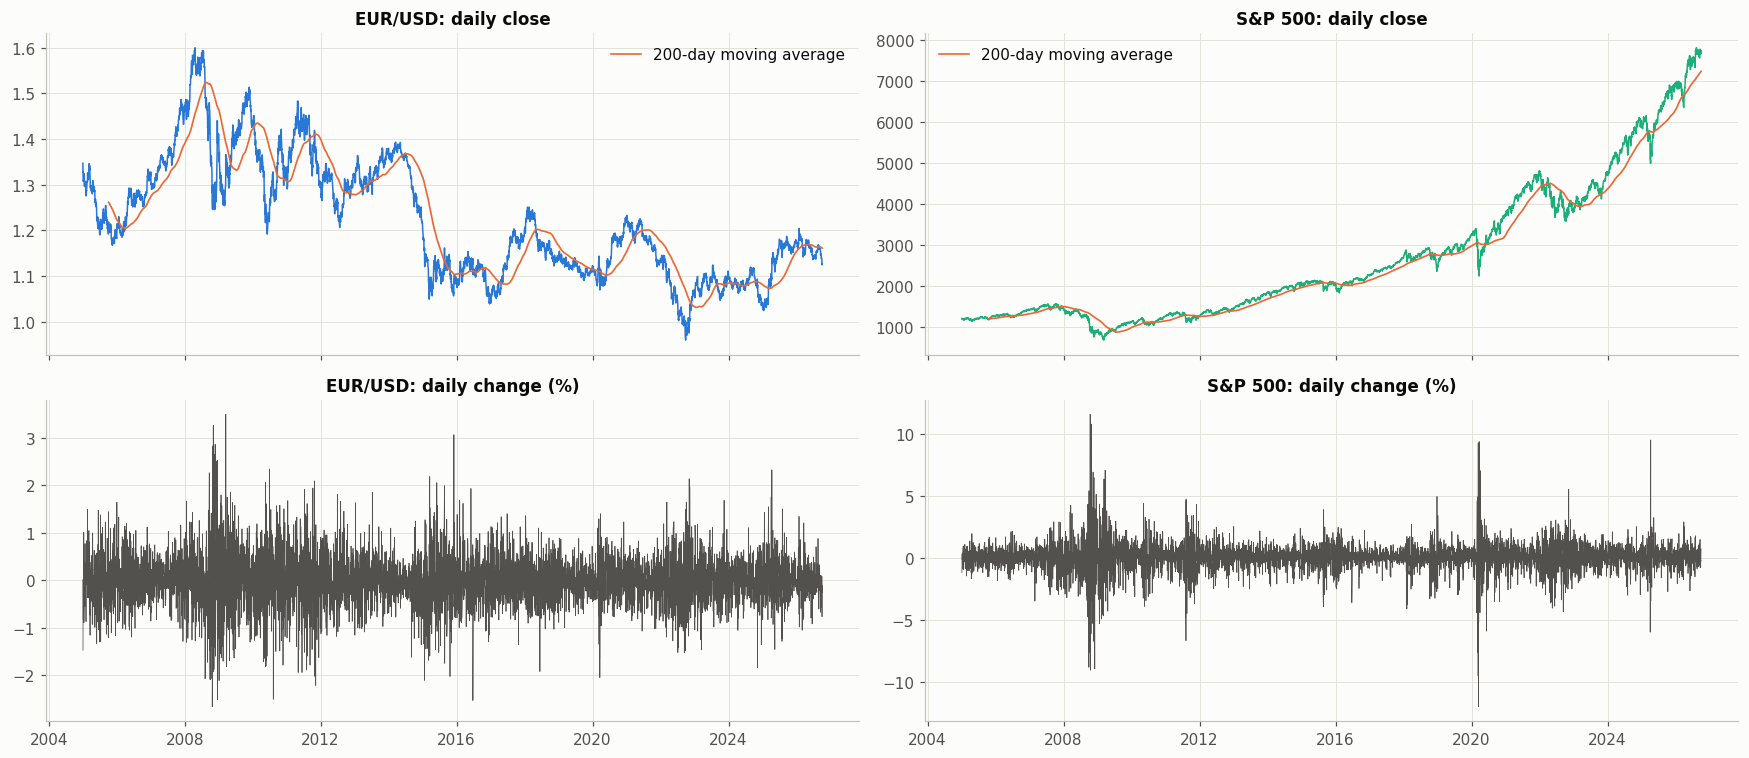

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(16, 7), sharex="col")
for j, name in enumerate(MARKETS):
    d = DF[name]; col = MK_COL[name]
    ax[0, j].plot(d.close, color=col, lw=1); ax[0, j].plot(d.close.rolling(200).mean(), color="#eb6834", lw=1.1, label="200-day moving average")
    ax[0, j].set_title(f"{name}: daily close"); ax[0, j].legend()
    ax[1, j].plot(d.close.pct_change() * 100, color=INK2, lw=0.5); ax[1, j].set_title(f"{name}: daily change (%)")
plt.tight_layout(); plt.show()

**Reading.**
* **EUR/USD** moves in long cycles between about 0.96 and 1.60, with no lasting upward or downward drift. Its daily
  changes stay mostly within ±1 %.
* **S&P 500** has a strong long-term upward trend, interrupted by deep falls (2008-2009, 2020, 2022) and shorter
  corrections. Its daily changes are about twice as large, and they cluster in the crisis periods (2008 and 2020).

### 4.2 Statistics, stationarity and autocorrelation
* **Augmented Dickey–Fuller (ADF) test**: checks whether a series is **stationary**, that is whether its mean and
  variance stay stable over time. A p-value below 0.05 indicates a stationary series.
* **Autocorrelation (ACF)**: correlation between a series and its own past values at a given lag.

,EUR/USD,S&P 500
mean daily change %,-0.0017,0.0412
std of daily change %,0.5536,1.1952
annualised volatility %,8.7885,18.9728
skewness,0.1383,-0.2057
excess kurtosis,2.5191,13.1011
largest daily rise %,3.4903,11.5800
largest daily fall %,-2.6604,-11.9841
ADF p-value (price),0.2605,1.0000
ADF p-value (daily change),0.0000,0.0000
ACF lag 1 (daily change),-0.0042,-0.1212


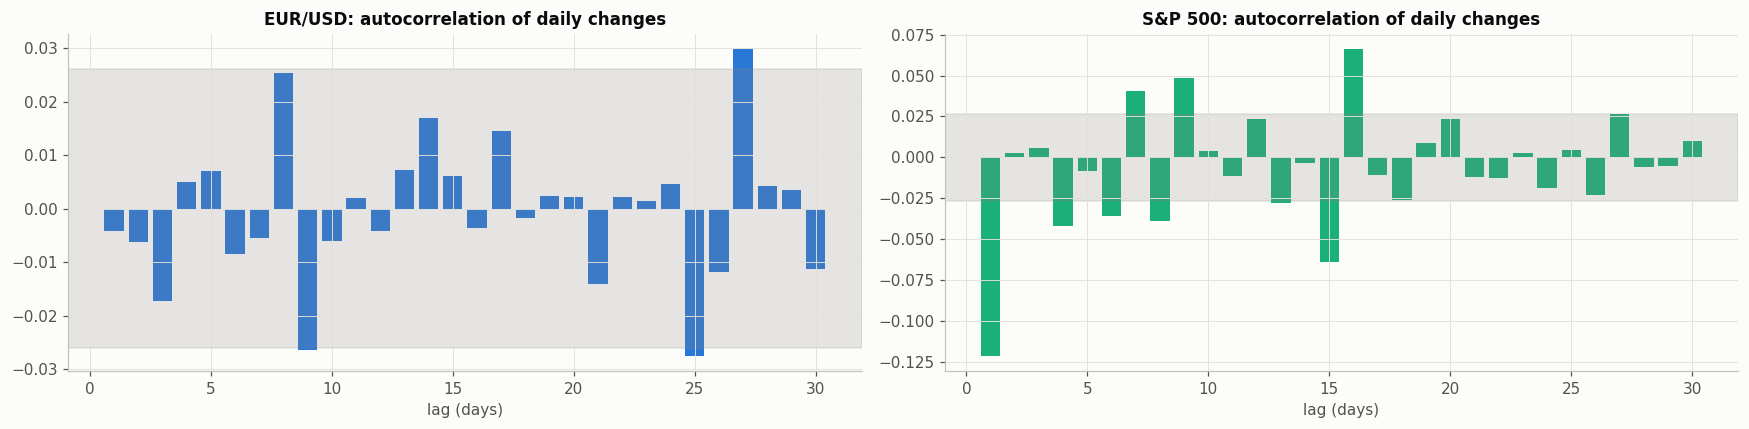

In [5]:
rows = {}
for name in MARKETS:
    c = DF[name].close; r = c.pct_change().dropna()
    rows[name] = {"mean daily change %": r.mean() * 100, "std of daily change %": r.std() * 100, "annualised volatility %": r.std() * np.sqrt(252) * 100,
                  "skewness": stats.skew(r), "excess kurtosis": stats.kurtosis(r), "largest daily rise %": r.max() * 100,
                  "largest daily fall %": r.min() * 100, "ADF p-value (price)": adfuller(c)[1], "ADF p-value (daily change)": adfuller(r)[1],
                  "ACF lag 1 (daily change)": acf(r, nlags=1)[1]}
STATS = pd.DataFrame(rows)
display(STATS.style.format("{:.4f}"))
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
for j, name in enumerate(MARKETS):
    r = DF[name].close.pct_change().dropna(); ci = 1.96 / np.sqrt(len(r))
    ax[j].bar(np.arange(1, 31), acf(r, nlags=30)[1:], color=MK_COL[name]); ax[j].axhspan(-ci, ci, color="#898781", alpha=.2)
    ax[j].set_title(f"{name}: autocorrelation of daily changes"); ax[j].set_xlabel("lag (days)")
plt.tight_layout(); plt.show()

**Reading.**

| Statistic | EUR/USD | S&P 500 | Meaning |
|---|---|---|---|
| Annualised volatility | 8.8 % | 19.0 % | the S&P 500 moves about twice as much |
| Skewness | +0.14 | −0.21 | the S&P 500 has slightly more large falls than large rises |
| Excess kurtosis | 2.5 | 13.1 | both have fat tails, much stronger for the S&P 500 (crash days) |
| Largest daily move | +3.5 % / −2.7 % | +11.6 % / −12.0 % | extreme days are far larger on the S&P 500 |
| ADF p-value, price | 0.26 | 1.00 | prices are **not stationary** |
| ADF p-value, daily change | 0.000 | 0.000 | daily changes **are stationary** |
| Autocorrelation at lag 1 | −0.004 | −0.12 | EUR/USD: none. S&P 500: a small **negative** autocorrelation, i.e. a slight tendency to partially reverse the previous day's move |

Because prices are not stationary and daily changes are, the feature-based models learn the **daily change** and the
forecast price is rebuilt from it. This is called **differencing**.

## 5. Feature engineering
Each row of the modelling table is one trading day and each column is a **feature** computed only from information
available at that day's close. Price-based features are expressed in **percent**, so that the same definitions work
for EUR/USD (around 1.1) and for the S&P 500 (several thousand points).

| Group | Features | Meaning |
|---|---|---|
| Lagged changes | % change at lags 1 to 10 | recent history |
| Moving averages | % distance to the 5, 10, 20, 50 and 200-day averages | position relative to short and long-term levels |
| Rolling statistics | 5, 20 and 60-day mean and standard deviation of % changes | recent drift and recent agitation |
| Candle shape | range, body, upper and lower wick (in % of the close) | how the day traded |
| Oscillators | RSI(14), position within the 20-day high-low range | classic technical indicators |
| Calendar | day of week, month | calendar effects |

**Target used by the feature-based models**: the next day's % change. The forecast price is rebuilt as
`close × (1 + predicted change)`. **Deep forecasting models** (section 8.8) work directly on the price series.

29 features | {'EUR/USD': '5,446 rows', 'S&P 500': '5,272 rows'}


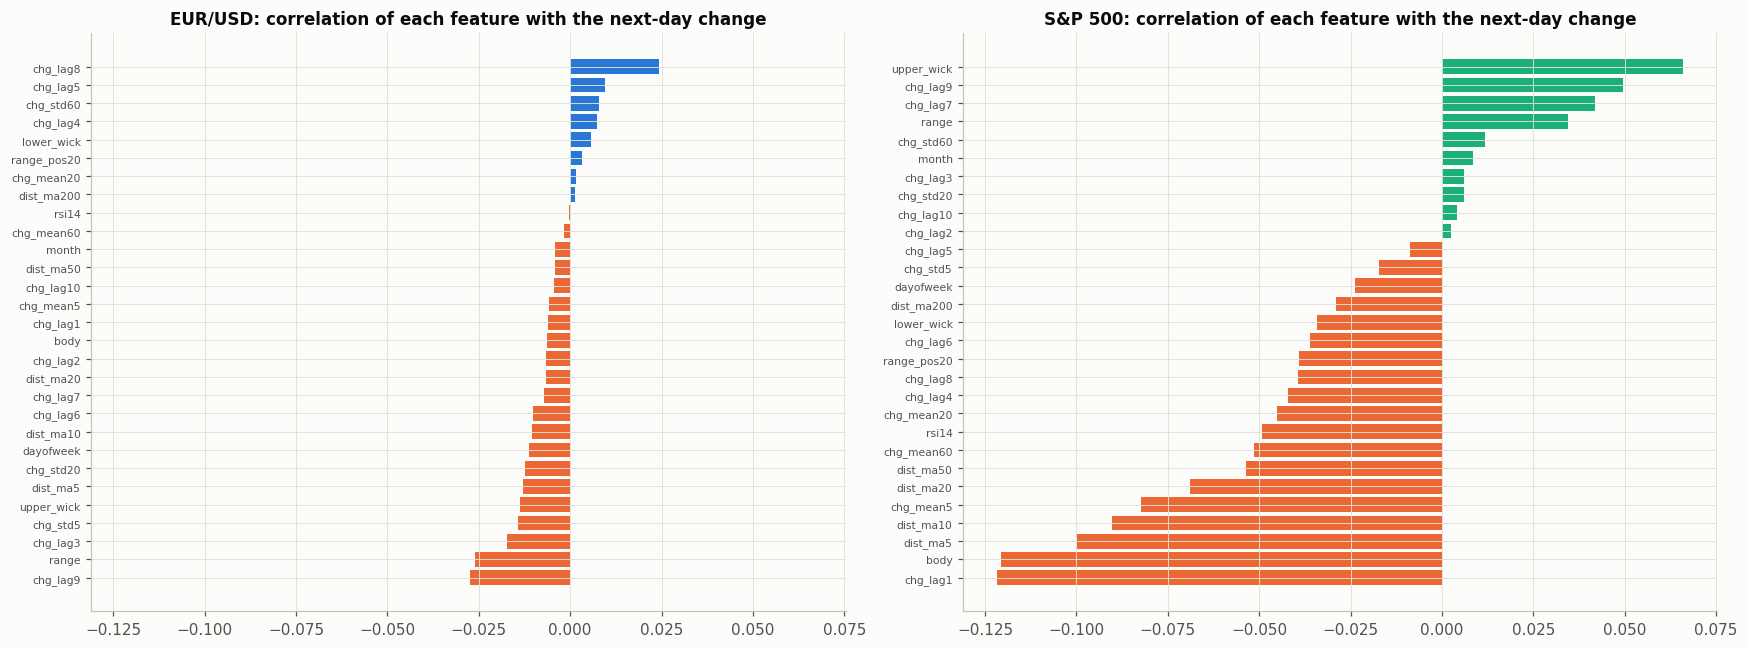

In [6]:
def make_features(d):
    c, h, l, o = d.close, d.high, d.low, d.open
    r = c.pct_change() * 100
    f = pd.DataFrame(index=d.index)
    for k in range(1, 11): f[f"chg_lag{k}"] = r.shift(k - 1)
    for n in (5, 10, 20, 50, 200): f[f"dist_ma{n}"] = (c / c.rolling(n).mean() - 1) * 100
    for n in (5, 20, 60): f[f"chg_mean{n}"] = r.rolling(n).mean(); f[f"chg_std{n}"] = r.rolling(n).std()
    f["range"], f["body"] = (h - l) / c * 100, (c - o) / c * 100
    f["upper_wick"], f["lower_wick"] = (h - np.maximum(c, o)) / c * 100, (np.minimum(c, o) - l) / c * 100
    up, dn = r.clip(lower=0).ewm(alpha=1 / 14).mean(), (-r.clip(upper=0)).ewm(alpha=1 / 14).mean()
    f["rsi14"] = 100 - 100 / (1 + up / dn)
    f["range_pos20"] = (c - l.rolling(20).min()) / (h.rolling(20).max() - l.rolling(20).min())
    f["dayofweek"], f["month"] = d.index.dayofweek, d.index.month
    return f

DATA = {}
for name in MARKETS:
    d = DF[name]; X = make_features(d)
    DATA[name] = X.assign(target=(d.close.shift(-1) / d.close - 1) * 100, close=d.close, next_close=d.close.shift(-1)).dropna()
FEATURES = [c for c in DATA["EUR/USD"].columns if c not in ("target", "close", "next_close")]
print(f"{len(FEATURES)} features |", {n: f"{len(v):,} rows" for n, v in DATA.items()})
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for j, name in enumerate(MARKETS):
    tc = DATA[name][FEATURES + ["target"]].corr()["target"].drop("target").sort_values()
    ax[j].barh(tc.index, tc.values, color=[("#eb6834" if v < 0 else MK_COL[name]) for v in tc.values]); ax[j].tick_params(axis="y", labelsize=7)
    ax[j].set_title(f"{name}: correlation of each feature with the next-day change")
plt.tight_layout(); plt.show()

**Reading.** For both markets, the correlation of each individual feature with the next-day change is small. On
the S&P 500, the lagged changes (above all lag 1) have the largest negative correlations, which is consistent with
the negative autocorrelation measured in section 4.2. On EUR/USD, all correlations are close to zero.

## 6. Train / validation / test split
The data is split **chronologically**. A random split would place future days in the training set, a problem
called **data leakage**, and make the evaluation unrealistically good.

| Set | Period | Use |
|---|---|---|
| **Train** | start → 2019 | fit the models |
| **Validation** | 2020 → 2022 | choose hyperparameters; early stopping for neural networks |
| **Test** | 2023 → end | final evaluation, used once |

Feature-based models are tuned on the validation set, refitted on train + validation, then evaluated on the test set.

In [7]:
SPLIT = {}
for name, data in DATA.items():
    tr = data.loc[:TRAIN_END]; va = data.loc[TRAIN_END:VALID_END]; va = va[va.index > tr.index[-1]]
    te = data.loc[VALID_END:]; te = te[te.index > va.index[-1]]
    SPLIT[name] = {"tr": tr, "va": va, "te": te, "trva": data.loc[:va.index[-1]]}
display(pd.DataFrame({n: {k: f"{v.index[0].date()} → {v.index[-1].date()} ({len(v):,} days)" for k, v in s.items() if k != "trva"} for n, s in SPLIT.items()}))

,EUR/USD,S&P 500
tr,"2005-10-07 → 2019-12-31 (3,694 days)","2005-10-17 → 2019-12-31 (3,576 days)"
va,2020-01-02 → 2022-12-30 (779 days),2020-01-02 → 2022-12-30 (756 days)
te,2023-01-02 → 2026-10-01 (973 days),2023-01-03 → 2026-10-01 (940 days)


## 7. Evaluation metrics
All metrics are computed on the **test set**, on the **price** forecast.

| Metric | Formula | What it measures | Source |
|---|---|---|---|
| **MAE** (Mean Absolute Error) | mean of \|actual − forecast\| | average size of the error, in price units (pips for EUR/USD, index points for the S&P 500) | Hyndman & Koehler (2006) |
| **RMSE** (Root Mean Squared Error) | √ mean of (actual − forecast)² | like MAE, but large errors weigh more | Hyndman & Koehler (2006) |
| **MAPE** (Mean Absolute Percentage Error) | mean of \|error\| / actual × 100 | average error in percent: comparable across markets | Hyndman & Koehler (2006) |
| **R²** (coefficient of determination) | 1 − Σ(error²) / Σ(actual − mean)² | share of the variance of the price explained by the forecast | standard regression metric |
| **Relative MAE** | MAE(model) / MAE(naive forecast) | **main comparison**: below 1 means more accurate than "tomorrow = today". This is the scaled-error idea of the MASE. | Hyndman & Koehler (2006) |
| **Diebold–Mariano test** (p-value) | test on the difference of squared errors between the model and the naive forecast | below 0.05: the accuracy difference is statistically significant for that single test | Diebold & Mariano (1995) |
| **Holm-adjusted p-value** | Diebold–Mariano p-values corrected for testing 33 algorithms at once | below 0.05: significant **after** accounting for the number of tests. With 33 tests at 5 %, one or two "significant" results are expected by chance alone; the Holm correction removes this effect | Holm (1979) |
| **Spread across seeds** | standard deviation of the relative MAE over 5 training runs with different random seeds | how much a neural network's result depends on its random initialisation | — |

**Why the relative MAE is the main metric.** Prices change little from one day to the next, so any forecast close
to today's price obtains a high R² and a small MAPE. Dividing the MAE of a model by the MAE of the naive forecast
measures the improvement each algorithm actually brings.

**Sources**
* Hyndman, R. J. & Koehler, A. B. (2006). *Another look at measures of forecast accuracy*. International Journal of Forecasting, 22(4).
* Diebold, F. X. & Mariano, R. S. (1995). *Comparing predictive accuracy*. Journal of Business & Economic Statistics, 13(3).
* Holm, S. (1979). *A simple sequentially rejective multiple test procedure*. Scandinavian Journal of Statistics, 6(2).
* Hyndman, R. J. & Athanasopoulos, G. *Forecasting: Principles and Practice* (3rd ed.), chapter 5.8 — https://otexts.com/fpp3/accuracy.html

In [8]:
def dm_pvalue(e1, e2):
    d = e1 ** 2 - e2 ** 2; n = len(d); L = int(n ** (1 / 3)); dc = d - d.mean()
    lrv = dc @ dc / n + 2 * sum((1 - l / (L + 1)) * (dc[l:] @ dc[:-l]) / n for l in range(1, L + 1))
    return 2 * (1 - stats.norm.cdf(abs(d.mean() / np.sqrt(lrv / n))))

def evaluate(pred, te, unit):
    actual, naive = te["next_close"].values, te["close"].values; e = actual - pred
    return {"MAE": mean_absolute_error(actual, pred) / unit, "RMSE": np.sqrt(mean_squared_error(actual, pred)) / unit,
            "MAPE %": np.mean(np.abs(e) / actual) * 100, "R2": r2_score(actual, pred),
            "Relative MAE": mean_absolute_error(actual, pred) / mean_absolute_error(actual, naive),
            "DM p-value": dm_pvalue(e, actual - naive) if not np.allclose(pred, naive) else np.nan}

## 8. The 34 algorithms: objective, how they work, sources
### 8.1 Baselines
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **Naive (persistence)** | the reference every model must beat | tomorrow's price = today's price | Hyndman & Athanasopoulos, *FPP3*, §5.2 |
| **Moving average (5 days)** | smooth out daily noise | tomorrow's price = average of the last 5 closes | Hyndman & Athanasopoulos, *FPP3*, §3.3 |

### 8.2 Statistical time-series models
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **Simple Exponential Smoothing (SES)** | forecast a series without trend, giving more weight to recent data | weighted average of past prices with weights decreasing exponentially; a parameter α ∈ [0, 1] sets how fast the past is forgotten | Brown (1956); *FPP3* §8.1 |
| **Holt's linear trend** | forecast a series with a trend | two smoothed components: level (α) and trend (β) | Holt (1957, reprinted in *Int. J. Forecasting* 2004); *FPP3* §8.2 |
| **ARIMA(p, d, q)** | model the linear dependence of a series on its past | the series is differenced *d* times to become stationary, then modelled from its *p* past values (autoregressive part) and *q* past errors (moving-average part); the order is chosen by the AIC criterion | Box & Jenkins (1970); *FPP3* chapter 9 |

### 8.3 Linear models
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **Linear Regression (OLS)** | find the best linear relation between features and target | minimises the sum of squared errors of y = w·x + b | Legendre (1805), Gauss (1809); scikit-learn docs |
| **Ridge** | stable linear model when features are correlated | OLS + L2 penalty α·Σw², which shrinks all weights | Hoerl & Kennard (1970), *Technometrics* |
| **Lasso** | linear model with automatic feature selection | OLS + L1 penalty α·Σ\|w\|, which can set weights exactly to zero | Tibshirani (1996), *JRSS B* |

### 8.4 Distance-based and kernel models
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **k-Nearest Neighbours (KNN)** | predict from the most similar past situations | finds the *k* past days whose features are closest (Euclidean distance) and averages their targets | Cover & Hart (1967), *IEEE Trans. Information Theory* |
| **Support Vector Regression (SVR)** | robust non-linear regression | fits a function that keeps errors inside a tube of width ε; the RBF kernel maps features into a space where non-linear relations become linear; C controls the fit/flatness trade-off | Drucker et al. (1997), *NeurIPS*; Smola & Schölkopf (2004), *Statistics and Computing* |

### 8.5 Tree-based models
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **Decision Tree (CART)** | readable non-linear rules | splits the data with yes/no questions on the features and predicts the mean target of each final leaf | Breiman, Friedman, Olshen & Stone (1984), *Classification and Regression Trees* |
| **Random Forest** | reduce the variance of a single tree | averages hundreds of trees, each trained on a bootstrap sample of the days and a random subset of the features (bagging) | Breiman (2001), *Machine Learning* |
| **Extra Trees** | further variance reduction | like Random Forest, but the split thresholds are drawn at random | Geurts, Ernst & Wehenkel (2006), *Machine Learning* |

### 8.6 Gradient boosting
Boosting builds trees **one after another**: each new tree fits the errors left by the previous ones, scaled by a
learning rate.

| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **Gradient Boosting** | reduce bias by sequential error correction | gradient descent in function space with regression trees | Friedman (2001), *Annals of Statistics* |
| **XGBoost** | fast, regularised boosting | second-order gradients, L1/L2 penalties on the leaves, histogram-based splits | Chen & Guestrin (2016), *KDD* |
| **LightGBM** | very fast boosting on large data | leaf-wise tree growth, histogram binning, gradient-based sampling | Ke et al. (2017), *NeurIPS* |
| **CatBoost** | boosting with less overfitting | symmetric (oblivious) trees and ordered boosting | Prokhorenkova et al. (2018), *NeurIPS* |

### 8.7 Neural networks (feature-based, PyTorch / scikit-learn)
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **MLP** (Multi-Layer Perceptron) | learn any non-linear function of the features | layers of neurons (weighted sum + ReLU activation) trained by backpropagation | Rumelhart, Hinton & Williams (1986), *Nature* |
| **LSTM** | learn from sequences with long memory | recurrent network reading the last 30 days; input, forget and output gates control a memory cell | Hochreiter & Schmidhuber (1997), *Neural Computation* |
| **GRU** | lighter recurrent network | two gates (update, reset) instead of three; fewer parameters | Cho et al. (2014), *EMNLP* |
| **1D CNN** | detect local temporal patterns | convolution filters slide along the 30-day sequence | LeCun et al. (1998), *Proc. IEEE*; Borovykh et al. (2017) |
| **Transformer** | relate every day of the sequence to every other day | self-attention layers weight the importance of each past day | Vaswani et al. (2017), *NeurIPS* "Attention Is All You Need" |

### 8.8 Deep forecasting models (Nixtla `neuralforecast`)
These architectures were designed specifically for time-series forecasting. They read a window of past **daily
closes** directly (no hand-made features) and predict the next close. Each window is normalised internally. The
window length (15 or 60 days) and the learning rate are chosen on the validation period.

| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **N-BEATS** | pure deep learning forecaster, no feature engineering | stacks of fully-connected blocks; each block removes the part of the input it explains (backcast) and adds its contribution to the forecast; winner of the M4 forecasting competition benchmark | Oreshkin et al. (2020), *ICLR* |
| **N-HiTS** | more accurate and faster N-BEATS | each block works at a different time resolution (multi-rate pooling) and interpolates its forecast | Challu et al. (2023), *AAAI* |
| **TiDE** | simple and fast long-horizon forecaster | MLP encoder–decoder with residual connections | Das et al. (2023), *TMLR* (Google) |
| **DLinear** | test whether a linear model is enough | decomposes the input into trend (moving average) and remainder, and applies one linear layer to each | Zeng et al. (2023), *AAAI* "Are Transformers Effective for Time Series Forecasting?" |
| **DeepAR** | probabilistic forecasting | autoregressive LSTM that outputs the parameters of a probability distribution (Student-t here) | Salinas et al. (2020), *Int. J. Forecasting* (Amazon) |
| **PatchTST** | Transformer adapted to time series | cuts the series into patches (sub-windows) used as tokens, then applies self-attention | Nie et al. (2023), *ICLR* |
| **TFT** (Temporal Fusion Transformer) | interpretable multi-horizon forecasting | variable-selection networks, LSTM encoder and interpretable multi-head attention | Lim et al. (2021), *Int. J. Forecasting* (Google) |
| **TCN** | convolutional alternative to recurrent networks | dilated causal convolutions: each output only sees the past, and the dilation widens the receptive field | Bai, Kolter & Koltun (2018), arXiv:1803.01271 |
| **BiTCN** | parameter-efficient convolutional forecaster | two temporal convolutional networks (past and future covariates) | Sprangers, Schelter & de Rijke (2023), *Int. J. Forecasting* |

### 8.9 Automated machine learning
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **H2O AutoML** | automatically train, tune and combine many models | trains GBMs, Random Forests, Extremely Randomised Trees, GLMs and deep neural networks within a time budget, then builds Stacked Ensembles; the best model on a held-out leaderboard set is selected | LeDell & Poirier (2020), *ICML AutoML Workshop* |

### 8.10 Ensembles
| Algorithm | Objective | How it works | Source |
|---|---|---|---|
| **Ensemble (deep learning)** | combine all neural forecasts | average of the (seed-averaged) forecasts of the 14 neural network and deep forecasting models | Bates & Granger (1969), *Operational Research Quarterly* |
| **Ensemble (all models)** | combine all forecasts | average of the forecasts of the 30 individual non-baseline models | Bates & Granger (1969); Timmermann (2006), *Handbook of Economic Forecasting* |

## 9. Training and evaluation
The function below applies the full pipeline to one market. **Every family is tuned on the validation period
(2020-2022)** before the single evaluation on the test period:

| Family | What is tuned on validation | Final training |
|---|---|---|
| Statistical | parameters estimated by maximum likelihood; ARIMA order chosen by AIC | train + validation |
| Linear, distance / kernel, trees, boosting, MLP | grid of hyperparameters | refit on train + validation |
| LSTM, GRU, 1D CNN, Transformer | hidden size (16 or 64) x learning rate (0.001 or 0.0003) | train, with early stopping on validation |
| Deep forecasting (N-BEATS to BiTCN) | input window (15 or 60 days) x learning rate (0.001 or 0.0003) | data up to the end of validation |
| H2O AutoML | its own internal search (120 s budget), ranked on validation data | train |

**Random seeds.** A neural network starts from random weights, so two training runs give slightly different
results. Every neural network (MLP, LSTM, GRU, 1D CNN, Transformer and the 9 deep forecasting models) is therefore
trained **5 times with 5 different seeds**. The tables report the **average** of the 5 runs and their **spread**
(standard deviation), and the charts use the average forecast of the 5 runs.

Slow models (deep forecasting, AutoML) are cached in `data/cache/`.

In [9]:
ML_MODELS = {
    "Linear Regression": ("Linear", lambda p: make_pipeline(StandardScaler(), LinearRegression()), [{}]),
    "Ridge":             ("Linear", lambda p: make_pipeline(StandardScaler(), Ridge(alpha=p["alpha"])), [{"alpha": a} for a in (1, 10, 100, 1000)]),
    "Lasso":             ("Linear", lambda p: make_pipeline(StandardScaler(), Lasso(alpha=p["alpha"], max_iter=5000)), [{"alpha": a} for a in (0.001, 0.01, 0.05, 0.1)]),
    "KNN":               ("Distance / kernel", lambda p: make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=p["k"])), [{"k": k} for k in (10, 50, 100, 200)]),
    "SVR (RBF)":         ("Distance / kernel", lambda p: make_pipeline(StandardScaler(), SVR(C=p["C"], epsilon=0.1, gamma="scale")), [{"C": c} for c in (0.01, 0.1, 1.0)]),
    "Decision Tree":     ("Trees", lambda p: DecisionTreeRegressor(max_depth=p["depth"], min_samples_leaf=50, random_state=SEED), [{"depth": d} for d in (2, 3, 5, 8)]),
    "Random Forest":     ("Trees", lambda p: RandomForestRegressor(n_estimators=300, max_depth=p["depth"], min_samples_leaf=p["leaf"], max_features=0.5, n_jobs=-1, random_state=SEED),
                          [{"depth": d, "leaf": l} for d in (4, 8) for l in (20, 100)]),
    "Extra Trees":       ("Trees", lambda p: ExtraTreesRegressor(n_estimators=300, max_depth=p["depth"], min_samples_leaf=p["leaf"], max_features=0.5, n_jobs=-1, random_state=SEED),
                          [{"depth": d, "leaf": l} for d in (4, 8) for l in (20, 100)]),
    "Gradient Boosting": ("Boosting", lambda p: GradientBoostingRegressor(n_estimators=p["n"], max_depth=p["depth"], learning_rate=0.02, subsample=0.8, random_state=SEED),
                          [{"n": n, "depth": d} for n in (100, 300) for d in (2, 3)]),
    "XGBoost":           ("Boosting", lambda p: xgb.XGBRegressor(n_estimators=p["n"], max_depth=p["depth"], learning_rate=0.02, subsample=0.8, colsample_bytree=0.7,
                                                                 reg_lambda=5, n_jobs=-1, random_state=SEED, verbosity=0), [{"n": n, "depth": d} for n in (100, 300) for d in (2, 4)]),
    "LightGBM":          ("Boosting", lambda p: lgb.LGBMRegressor(n_estimators=p["n"], num_leaves=p["leaves"], learning_rate=0.02, subsample=0.8, subsample_freq=1,
                                                                  colsample_bytree=0.7, min_child_samples=50, n_jobs=-1, random_state=SEED, verbose=-1),
                          [{"n": n, "leaves": lv} for n in (100, 300) for lv in (7, 15)]),
    "CatBoost":          ("Boosting", lambda p: CatBoostRegressor(iterations=p["n"], depth=p["depth"], learning_rate=0.03, random_seed=SEED, verbose=0, thread_count=-1,
                                                                   allow_writing_files=False), [{"n": n, "depth": d} for n in (200, 500) for d in (4, 6)]),
    "MLP":               ("Neural networks", lambda p: make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=p["h"], alpha=p["alpha"], early_stopping=True,
                                                                     validation_fraction=0.15, max_iter=500, random_state=SEED)),
                          [{"h": h, "alpha": a} for h in ((32,), (64, 32)) for a in (0.01, 1.0)]),
}

SEQ = 30
SEEDS = [0, 1, 2, 3, 4]
TORCH_GRID = [{"hidden": h, "lr": lr} for h in (16, 64) for lr in (1e-3, 3e-4)]
NF_GRID = [{"input_size": i, "learning_rate": lr} for i in (15, 60) for lr in (1e-3, 3e-4)]

class RNN(nn.Module):
    def __init__(self, cell, n_in, h=32):
        super().__init__(); self.rnn = cell(n_in, h, batch_first=True); self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(h, 1))
    def forward(self, x): o, _ = self.rnn(x); return self.head(o[:, -1]).squeeze(-1)
class CNN1D(nn.Module):
    def __init__(self, n_in, ch=32):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(n_in, ch, 3, padding=1), nn.ReLU(), nn.Conv1d(ch, ch, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(ch, 1))
    def forward(self, x): return self.head(self.net(x.transpose(1, 2)).squeeze(-1)).squeeze(-1)
class TransformerNet(nn.Module):
    def __init__(self, n_in, d=32):
        super().__init__(); self.inp = nn.Linear(n_in, d); self.pos = nn.Parameter(torch.zeros(1, SEQ, d))
        self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, nhead=4, dim_feedforward=2 * d, dropout=0.2, batch_first=True), num_layers=2)
        self.head = nn.Linear(d, 1)
    def forward(self, x): return self.head(self.enc(self.inp(x) + self.pos)[:, -1]).squeeze(-1)
TORCH_NETS = {"LSTM": lambda k, h: RNN(nn.LSTM, k, h), "GRU": lambda k, h: RNN(nn.GRU, k, h),
              "1D CNN": lambda k, h: CNN1D(k, h), "Transformer": lambda k, h: TransformerNet(k, h)}

def train_torch(make, n_in, cfg, seed, Xt, yt, Xv, yv):
    torch.manual_seed(seed); net = make(n_in, cfg["hidden"])
    opt = torch.optim.Adam(net.parameters(), lr=cfg["lr"], weight_decay=1e-4); lossf = nn.MSELoss()
    best, state, bad, hist = np.inf, None, 0, {"train": [], "validation": []}
    for ep in range(100):
        net.train(); perm = torch.randperm(len(Xt)); tl = []
        for b in range(0, len(perm), 64):
            j = perm[b:b + 64]; opt.zero_grad(); l_ = lossf(net(Xt[j]), yt[j]); l_.backward(); opt.step(); tl.append(l_.item())
        net.eval()
        with torch.no_grad(): vl = lossf(net(Xv), yv).item()
        hist["train"].append(np.mean(tl)); hist["validation"].append(vl)
        if vl < best - 1e-5: best, state, bad = vl, {k: v.clone() for k, v in net.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= 8: break
    net.load_state_dict(state); net.eval(); return net, hist

NF_COMMON = dict(h=1, max_steps=1000, scaler_type="standard", batch_size=32, windows_batch_size=256,
                 early_stop_patience_steps=5, val_check_steps=50,
                 enable_progress_bar=False, enable_model_summary=False, logger=False, accelerator="cpu")
NF_SPECS = {"N-BEATS": (NBEATS, dict(stack_types=["identity"] * 3)), "N-HiTS": (NHITS, {}), "TiDE": (TiDE, dict(hidden_size=128)),
            "DLinear": (DLinear, dict(moving_avg_window=15)), "DeepAR": (DeepAR, dict(lstm_hidden_size=64)),
            "PatchTST": (PatchTST, dict(hidden_size=64, n_heads=4, patch_len=8, stride=4)), "TFT": (TFT, dict(hidden_size=32)),
            "TCN": (TCN, dict(encoder_hidden_size=64)), "BiTCN": (BiTCN, dict(hidden_size=16))}
def nf_model(name, cfg, seed):
    cls, extra = NF_SPECS[name]; params = set(inspect.signature(cls.__init__).parameters)
    allkw = {**NF_COMMON, **extra, **cfg, "random_seed": seed}
    kw = {k: v for k, v in allkw.items() if k in params or k in ("enable_progress_bar", "enable_model_summary", "logger", "accelerator")}
    kw["loss"] = DistributionLoss("StudentT", level=[80]) if name == "DeepAR" else NF_MAE()
    m = cls(**kw); m.alias = name; return m

def nf_predict(name, cfg, seed, series_values, tgt_pos, key, tag):
    cache = DATA_DIR / "cache" / f"nf_{key}_{name}_{tag}_{cfg['input_size']}_{cfg['learning_rate']}_{seed}.npz"
    if cache.exists():
        z = np.load(cache); return z["p"], float(z["t"])
    df_nf = pd.DataFrame({"unique_id": key, "ds": np.arange(tgt_pos[-1] + 1), "y": series_values[:tgt_pos[-1] + 1]})
    t0 = time.time()
    cv = NeuralForecast(models=[nf_model(name, cfg, seed)], freq=1).cross_validation(df_nf, n_windows=len(tgt_pos), step_size=1, refit=False, val_size=250)
    cv = cv.sort_values("ds"); assert (cv.ds.values == tgt_pos).all()
    p, t = cv[name].values, time.time() - t0; np.savez(cache, p=p, t=t); return p, t

In [10]:
def run_market(name):
    S = SPLIT[name]; tr, va, te, trva = S["tr"], S["va"], S["te"], S["trva"]; unit = MARKETS[name]["unit"]
    close_all = DF[name].close; key = name.replace("/", "").replace("&", "").replace(" ", "")
    PRED, SEEDED, TIME, FAM, INFO = {}, {}, {}, {}, {"best_params": {}, "history": {}}
    def reg(n, fam, p, t): PRED[n], TIME[n], FAM[n] = np.asarray(p, dtype=float), t, fam
    def reg_seeds(n, fam, preds, t): SEEDED[n] = [np.asarray(p, dtype=float) for p in preds]; reg(n, fam, np.mean(preds, axis=0), t)
    to_price = lambda chg_pct, part=te: part["close"].values * (1 + chg_pct / 100)

    # baselines
    reg("Naive", "Baseline", te["close"].values, 0.0)
    reg("Moving average (5d)", "Baseline", close_all.rolling(5).mean().reindex(te.index).values, 0.0)
    # statistical models: fitted on train + validation, one-step-ahead forecasts on the test period
    last = close_all.index.get_loc(te.index[-1]) + 1; series = close_all.iloc[:last]; n_fit = close_all.index.get_loc(trva.index[-1]) + 1
    t0 = time.time(); f = SimpleExpSmoothing(series.iloc[:n_fit].values, initialization_method="estimated").fit()
    full = SimpleExpSmoothing(series.values, initialization_method="known", initial_level=f.params["initial_level"]).fit(smoothing_level=f.params["smoothing_level"], optimized=False)
    reg("Simple Exp. Smoothing", "Statistical", pd.Series(np.r_[full.fittedvalues[1:], full.forecast(1)], index=series.index).reindex(te.index).values, time.time() - t0)
    INFO["ses_alpha"] = f.params["smoothing_level"]
    t0 = time.time(); f = ExponentialSmoothing(series.iloc[:n_fit].values, trend="add", initialization_method="estimated").fit()
    full = ExponentialSmoothing(series.values, trend="add", initialization_method="known", initial_level=f.params["initial_level"], initial_trend=f.params["initial_trend"]).fit(
        smoothing_level=f.params["smoothing_level"], smoothing_trend=f.params["smoothing_trend"], optimized=False)
    reg("Holt (trend)", "Statistical", pd.Series(np.r_[full.fittedvalues[1:], full.forecast(1)], index=series.index).reindex(te.index).values, time.time() - t0)
    INFO["holt"] = (f.params["smoothing_level"], f.params["smoothing_trend"])
    t0 = time.time(); aics = {o: ARIMA(series.iloc[:n_fit].values, order=o).fit().aic for o in [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 0), (2, 1, 2)]}
    order = min(aics, key=aics.get); res = ARIMA(series.iloc[:n_fit].values, order=order).fit().apply(series.values)
    reg("ARIMA", "Statistical", pd.Series(res.get_prediction(start=1, end=len(series)).predicted_mean, index=series.index).reindex(te.index).values, time.time() - t0)
    INFO["arima_order"] = order

    # feature-based machine learning models: grid search on validation, refit on train + validation
    Xtr, Xva, Xtrva, Xte = tr[FEATURES].values, va[FEATURES].values, trva[FEATURES].values, te[FEATURES].values
    for n, (fam, make, grid) in ML_MODELS.items():
        scores = [mean_absolute_error(va["next_close"], to_price(make(p).fit(Xtr, tr["target"]).predict(Xva), va)) for p in grid]
        best = grid[int(np.argmin(scores))]; INFO["best_params"][n] = best
        t0 = time.time()
        if n == "MLP":   # neural network: 5 random seeds
            preds = []
            for s in SEEDS:
                m = make(best); m.set_params(mlpregressor__random_state=s); preds.append(to_price(m.fit(Xtrva, trva["target"]).predict(Xte)))
            reg_seeds(n, fam, preds, (time.time() - t0) / len(SEEDS))
        else:
            m = make(best).fit(Xtrva, trva["target"]); reg(n, fam, to_price(m.predict(Xte)), time.time() - t0)

    # sequence neural networks (PyTorch): hidden size and learning rate chosen on validation, then 5 seeds
    data = DATA[name]; sc = StandardScaler().fit(tr[FEATURES]); XS = np.clip(sc.transform(data[FEATURES]), -6, 6).astype(np.float32)
    ysd = tr["target"].std(); YS = (data["target"].values / ysd).astype(np.float32); pos = {d: i for i, d in enumerate(data.index)}
    keep = lambda part: part[[pos[d] >= SEQ for d in part.index]]
    va_s, te_s = keep(va), keep(te)
    seq = lambda idx: torch.tensor(np.stack([XS[i - SEQ + 1:i + 1] for i in idx]))
    i_tr = np.array([pos[d] for d in tr.index if pos[d] >= SEQ]); i_va = np.array([pos[d] for d in va_s.index]); i_te = np.array([pos[d] for d in te_s.index])
    Xt, Xv, Xs = seq(i_tr), seq(i_va), seq(i_te); yt, yv = torch.tensor(YS[i_tr]), torch.tensor(YS[i_va])
    for n, make in TORCH_NETS.items():
        val_mae = {}
        for k, cfg in enumerate(TORCH_GRID):
            net, _ = train_torch(make, len(FEATURES), cfg, SEED, Xt, yt, Xv, yv)
            with torch.no_grad(): pv = net(Xv).numpy() * ysd
            val_mae[k] = mean_absolute_error(va_s["next_close"], to_price(pv, va_s))
        cfg = TORCH_GRID[min(val_mae, key=val_mae.get)]; INFO["best_params"][n] = cfg
        preds, t0 = [], time.time()
        for s in SEEDS:
            net, hist = train_torch(make, len(FEATURES), cfg, s, Xt, yt, Xv, yv)
            with torch.no_grad(): preds.append(to_price(net(Xs).numpy() * ysd, te_s))
            if s == SEEDS[0]: INFO["history"][n] = hist
        reg_seeds(n, "Neural networks", preds, (time.time() - t0) / len(SEEDS))

    # deep forecasting models (neuralforecast): input window and learning rate chosen on validation, then 5 seeds
    pos_c = {d: i for i, d in enumerate(close_all.index)}
    tgt_va = np.array([pos_c[d] + 1 for d in va.index]); tgt_te = np.array([pos_c[d] + 1 for d in te.index])
    for n in NF_SPECS:
        val_mae = {}
        for k, cfg in enumerate(NF_GRID):
            pv, _ = nf_predict(n, cfg, SEED, close_all.values, tgt_va, key, "val")
            val_mae[k] = mean_absolute_error(va["next_close"], pv)
        cfg = NF_GRID[min(val_mae, key=val_mae.get)]; INFO["best_params"][n] = cfg
        runs = [nf_predict(n, cfg, s, close_all.values, tgt_te, key, "test") for s in SEEDS]
        reg_seeds(n, "Deep forecasting", [p for p, _ in runs], float(np.mean([t for _, t in runs])))

    # H2O AutoML: target = next-day change, trained on train, blending / leaderboard on the validation period
    cache = DATA_DIR / "cache" / f"h2o_{key}.npz"
    if cache.exists():
        z = np.load(cache, allow_pickle=True); reg("H2O AutoML", "AutoML", z["p"], float(z["t"])); INFO["h2o_leader"] = str(z["leader"])
    else:
        h2o.init(nthreads=-1, max_mem_size="6G", verbose=False); h2o.no_progress(); t0 = time.time()
        frame = lambda d: h2o.H2OFrame(d[FEATURES + ["target"]])
        half = len(va) // 2
        aml = H2OAutoML(max_runtime_secs=H2O_BUDGET, nfolds=0, seed=SEED, sort_metric="MAE", verbosity=None)
        aml.train(x=FEATURES, y="target", training_frame=frame(tr), blending_frame=frame(va.iloc[:half]), leaderboard_frame=frame(va.iloc[half:]))
        p = aml.leader.predict(h2o.H2OFrame(te[FEATURES])).as_data_frame()["predict"].values
        t = time.time() - t0; leader = aml.leader.model_id; np.savez(cache, p=to_price(p), t=t, leader=leader)
        reg("H2O AutoML", "AutoML", to_price(p), t); INFO["h2o_leader"] = leader

    # ensembles (built from the seed-averaged forecasts)
    deep = [n for n in PRED if FAM[n] in ("Neural networks", "Deep forecasting")]
    allm = [n for n in PRED if FAM[n] != "Baseline"]
    reg("Ensemble (deep learning)", "Ensembles", np.mean([PRED[n] for n in deep], axis=0), sum(TIME[n] for n in deep))
    reg("Ensemble (all models)", "Ensembles", np.mean([PRED[n] for n in allm], axis=0), sum(TIME[n] for n in allm))

    # evaluation: seeded models -> mean of the per-seed metrics, spread across seeds, median DM p-value
    rows = {}
    for n, p in PRED.items():
        if n in SEEDED:
            ms = [evaluate(q, te, unit) for q in SEEDED[n]]
            m = {k: float(np.nanmean([x[k] for x in ms])) for k in ms[0]}
            m["DM p-value"] = float(np.nanmedian([x["DM p-value"] for x in ms]))
            m["Rel. MAE std (5 seeds)"] = float(np.std([x["Relative MAE"] for x in ms]))
        else:
            m = evaluate(p, te, unit); m["Rel. MAE std (5 seeds)"] = np.nan
        rows[n] = {"Family": FAM[n], **m, "Training time (s)": TIME[n]}
    res = pd.DataFrame(rows).T
    for c in res.columns[1:]: res[c] = res[c].astype(float)
    tested = res["DM p-value"].notna()
    res.loc[tested, "DM p (Holm)"] = multipletests(res.loc[tested, "DM p-value"], method="holm")[1]
    res["Significant (Holm 5%)"] = res["DM p (Holm)"] < 0.05
    res = res.sort_values("Relative MAE"); res.insert(1, "Rank", np.arange(1, len(res) + 1))
    return {"pred": PRED, "seeded": SEEDED, "fam": FAM, "res": res, "info": INFO}

OUT = {}
for name in MARKETS:
    t0 = time.time(); OUT[name] = run_market(name)
    print(f"{name}: {len(OUT[name]['pred'])} algorithms evaluated in {time.time() - t0:.0f}s")
try: h2o.cluster().shutdown()
except Exception: pass

EUR/USD: 34 algorithms evaluated in 1990s


S&P 500: 34 algorithms evaluated in 2345s


## 10. Results: EUR/USD
### 10.1 Test-set metrics
MAE and RMSE are expressed in **pips (1 pip = 0.0001)**.

In [11]:
mk = "EUR/USD"; R = OUT[mk]["res"]; info = OUT[mk]["info"]
print(f"ARIMA order selected by AIC: {info['arima_order']} | SES alpha = {info['ses_alpha']:.3f} | Holt alpha, beta = {info['holt'][0]:.3f}, {info['holt'][1]:.3f} | H2O leader: {info['h2o_leader']}")
print("Hyperparameters selected on the validation set:"); print({k: v for k, v in info["best_params"].items()})
display(R.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "MAPE %": "{:.3f}", "R2": "{:.4f}", "Relative MAE": "{:.4f}", "DM p-value": "{:.3f}",
                        "DM p (Holm)": "{:.3f}", "Rel. MAE std (5 seeds)": "{:.4f}", "Training time (s)": "{:.1f}"}, na_rep="-")
        .background_gradient(subset=["Relative MAE"], cmap="RdYlGn_r", vmin=0.98, vmax=1.05))

ARIMA order selected by AIC: (0, 1, 0) | SES alpha = 0.996 | Holt alpha, beta = 0.996, 0.000 | H2O leader: GBM_grid_1_AutoML_1_20261005_02243_model_7
Hyperparameters selected on the validation set:
{'Linear Regression': {}, 'Ridge': {'alpha': 100}, 'Lasso': {'alpha': 0.05}, 'KNN': {'k': 200}, 'SVR (RBF)': {'C': 0.01}, 'Decision Tree': {'depth': 2}, 'Random Forest': {'depth': 4, 'leaf': 100}, 'Extra Trees': {'depth': 4, 'leaf': 100}, 'Gradient Boosting': {'n': 100, 'depth': 2}, 'XGBoost': {'n': 100, 'depth': 2}, 'LightGBM': {'n': 100, 'leaves': 7}, 'CatBoost': {'n': 200, 'depth': 4}, 'MLP': {'h': (32,), 'alpha': 1.0}, 'LSTM': {'hidden': 16, 'lr': 0.0003}, 'GRU': {'hidden': 64, 'lr': 0.0003}, '1D CNN': {'hidden': 16, 'lr': 0.001}, 'Transformer': {'hidden': 64, 'lr': 0.001}, 'N-BEATS': {'input_size': 60, 'learning_rate': 0.001}, 'N-HiTS': {'input_size': 15, 'learning_rate': 0.001}, 'TiDE': {'input_size': 15, 'learning_rate': 0.001}, 'DLinear': {'input_size': 15, 'learning_rate': 0.001}, '

,Family,Rank,MAE,RMSE,MAPE %,R2,Relative MAE,DM p-value,Rel. MAE std (5 seeds),Training time (s),DM p (Holm),Significant (Holm 5%)
SVR (RBF),Distance / kernel,1,35.88,47.78,0.324,0.9879,0.9987,0.975,-,1.0,1.000,False
KNN,Distance / kernel,2,35.88,47.81,0.324,0.9878,0.9989,0.803,-,0.0,1.000,False
Ensemble (all models),Ensembles,3,35.89,47.82,0.324,0.9878,0.9991,0.788,-,294.5,1.000,False
Holt (trend),Statistical,4,35.90,47.80,0.324,0.9878,0.9994,0.675,-,0.1,1.000,False
Gradient Boosting,Boosting,5,35.91,47.78,0.324,0.9879,0.9996,0.735,-,1.4,1.000,False
Simple Exp. Smoothing,Statistical,6,35.92,47.79,0.324,0.9879,0.9998,0.728,-,0.0,1.000,False
Lasso,Linear,7,35.92,47.79,0.324,0.9879,0.9999,0.696,-,0.0,1.000,False
XGBoost,Boosting,8,35.92,47.79,0.324,0.9879,0.9999,0.926,-,0.1,1.000,False
ARIMA,Statistical,9,35.92,47.79,0.324,0.9879,1.0000,-,-,1.6,-,False
Naive,Baseline,10,35.92,47.79,0.324,0.9879,1.0000,-,-,0.0,-,False


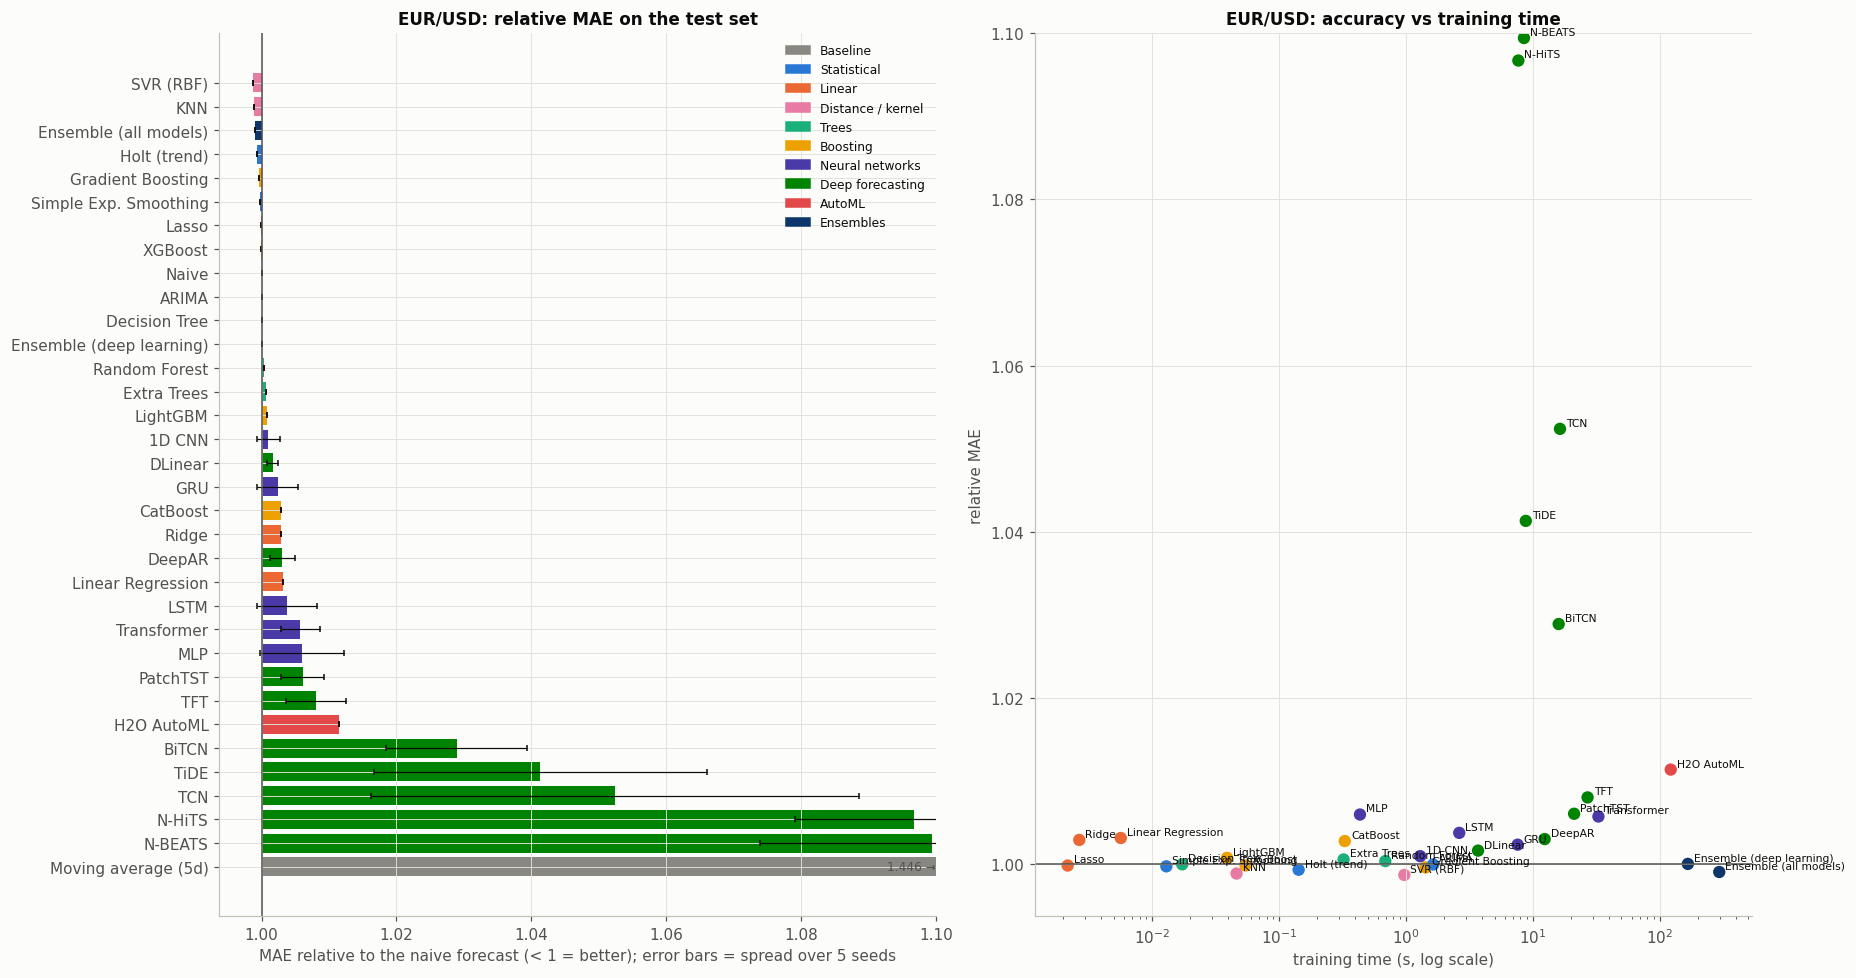

In [12]:
mk = "EUR/USD"; R = OUT[mk]["res"]
fig, ax = plt.subplots(1, 2, figsize=(17, 9))
r = R.sort_values("Relative MAE", ascending=False)
ax[0].barh(r.index, r["Relative MAE"] - 1, left=1, color=[FAM_COL[f] for f in r.Family], xerr=r["Rel. MAE std (5 seeds)"].fillna(0).values,
           error_kw=dict(ecolor=INK, lw=0.8, capsize=2)); ax[0].axvline(1, color=INK2, lw=1)
lo, hi = max(0.95, r["Relative MAE"].min() - 0.005), min(1.10, max(1.01, r["Relative MAE"].quantile(0.95) + 0.005)); ax[0].set_xlim(lo, hi)
for i, v in enumerate(r["Relative MAE"]):
    if v > hi: ax[0].text(hi, i, f"{v:.3f} →", va="center", ha="right", fontsize=8, color=INK2)
ax[0].set_xlabel("MAE relative to the naive forecast (< 1 = better); error bars = spread over 5 seeds"); ax[0].set_title(f"{mk}: relative MAE on the test set")
ax[0].legend(handles=[Patch(color=c, label=f) for f, c in FAM_COL.items()], loc="upper right", fontsize=8)
t = R[R["Training time (s)"] > 0]
ax[1].scatter(t["Training time (s)"], t["Relative MAE"], s=50, color=[FAM_COL[f] for f in t.Family])
for n, row in t.iterrows(): ax[1].annotate(n, (row["Training time (s)"], row["Relative MAE"]), fontsize=7, xytext=(4, 2), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].axhline(1, color=INK2, lw=1); ax[1].set_ylim(lo, hi)
ax[1].set_xlabel("training time (s, log scale)"); ax[1].set_ylabel("relative MAE"); ax[1].set_title(f"{mk}: accuracy vs training time")
plt.tight_layout(); plt.show()

### Explanation of the EUR/USD results
**Overall.** On the 973 test days (2023 to October 2026), the naive forecast has an MAE of **35.92 pips**. **8
algorithms** have a relative MAE below 1, between **0.9987 and 0.9999**: they are at most 0.13 % (0.05 pips) more
accurate than the naive forecast. **No algorithm is significantly better than the naive forecast**, neither before
the multiple-testing correction (all Diebold–Mariano p-values above 0.67) nor after it. R² is 0.988 and MAPE 0.32 %
for nearly every model, so these two metrics do not separate the algorithms.

| Rank | Algorithm | Relative MAE | Explanation |
|---|---|---|---|
| 1 | **SVR (RBF)** | 0.9987 | smallest C selected (0.01), i.e. the flattest function: the predicted changes are very small |
| 2 | **KNN** | 0.9989 | k = 200: the forecast averages many similar past days, which gives a change close to zero |
| 3 | **Ensemble (all models)** | 0.9991 | averaging the 30 individual forecasts cancels part of their individual errors |
| 4-8 | Holt, Gradient Boosting, SES, Lasso, XGBoost | 0.9994-0.9999 | almost the naive forecast: Holt and SES give almost all the weight to the last price (α = 0.996, β = 0); Lasso removes every feature; the boosting models keep only 100 shallow trees |
| 9-11 | ARIMA, Naive, Decision Tree | 1.0000 | AIC selected ARIMA(0,1,0), which **is** the random walk; the depth-2 tree predicts an almost constant change |
| 12-25 | Ensemble (deep learning), Random Forest, Extra Trees, LightGBM, 1D CNN, DLinear, GRU, CatBoost, Ridge, DeepAR, Linear Regression, LSTM, Transformer, MLP | 1.0001-1.0060 | slightly less accurate than naive, not significant |
| 26-28 | PatchTST, TFT, H2O AutoML | 1.006-1.011 | not significant after correction |
| 29-33 | **BiTCN, TiDE, TCN, N-HiTS, N-BEATS** | 1.029-1.099 | TiDE, TCN, N-HiTS and N-BEATS are **significantly worse** than the naive forecast after the Holm correction |
| 34 | Moving average (5d) | 1.446 | structural lag behind the price |

**Effect of the random seeds.** The spread over 5 seeds ranges from 0.0008 (DLinear) to 0.036 (TCN). For the neural
networks in the middle of the table (1D CNN, GRU, DeepAR, LSTM, Transformer, MLP), the differences between their
relative MAEs are of the same size as their seed spreads (0.002-0.006). Their order is therefore not meaningful: a
different seed could swap them.

**Effect of tuning the deep forecasting models.** Tuning the input window and the learning rate on the validation
period improved several deep forecasting models compared with a fixed 30-day configuration. TFT, BiTCN, TiDE and TCN
moved closer to the naive forecast, while N-BEATS and N-HiTS remain about 10 % worse. Validation selected the short
15-day window for 8 of the 9 models (all except N-BEATS).

**Hyperparameters chosen on the validation set.** The selected settings are among the most regularised of each
grid: Ridge α = 100, a Lasso α that removes every feature, k = 200 for KNN, C = 0.01 for SVR, depth-2 trees, 100
boosting rounds, and the strongest MLP penalty. These settings produce forecasts very close to "no change".

### 10.2 Forecasts of the 8 best algorithms and the naive forecast (last 60 test days)

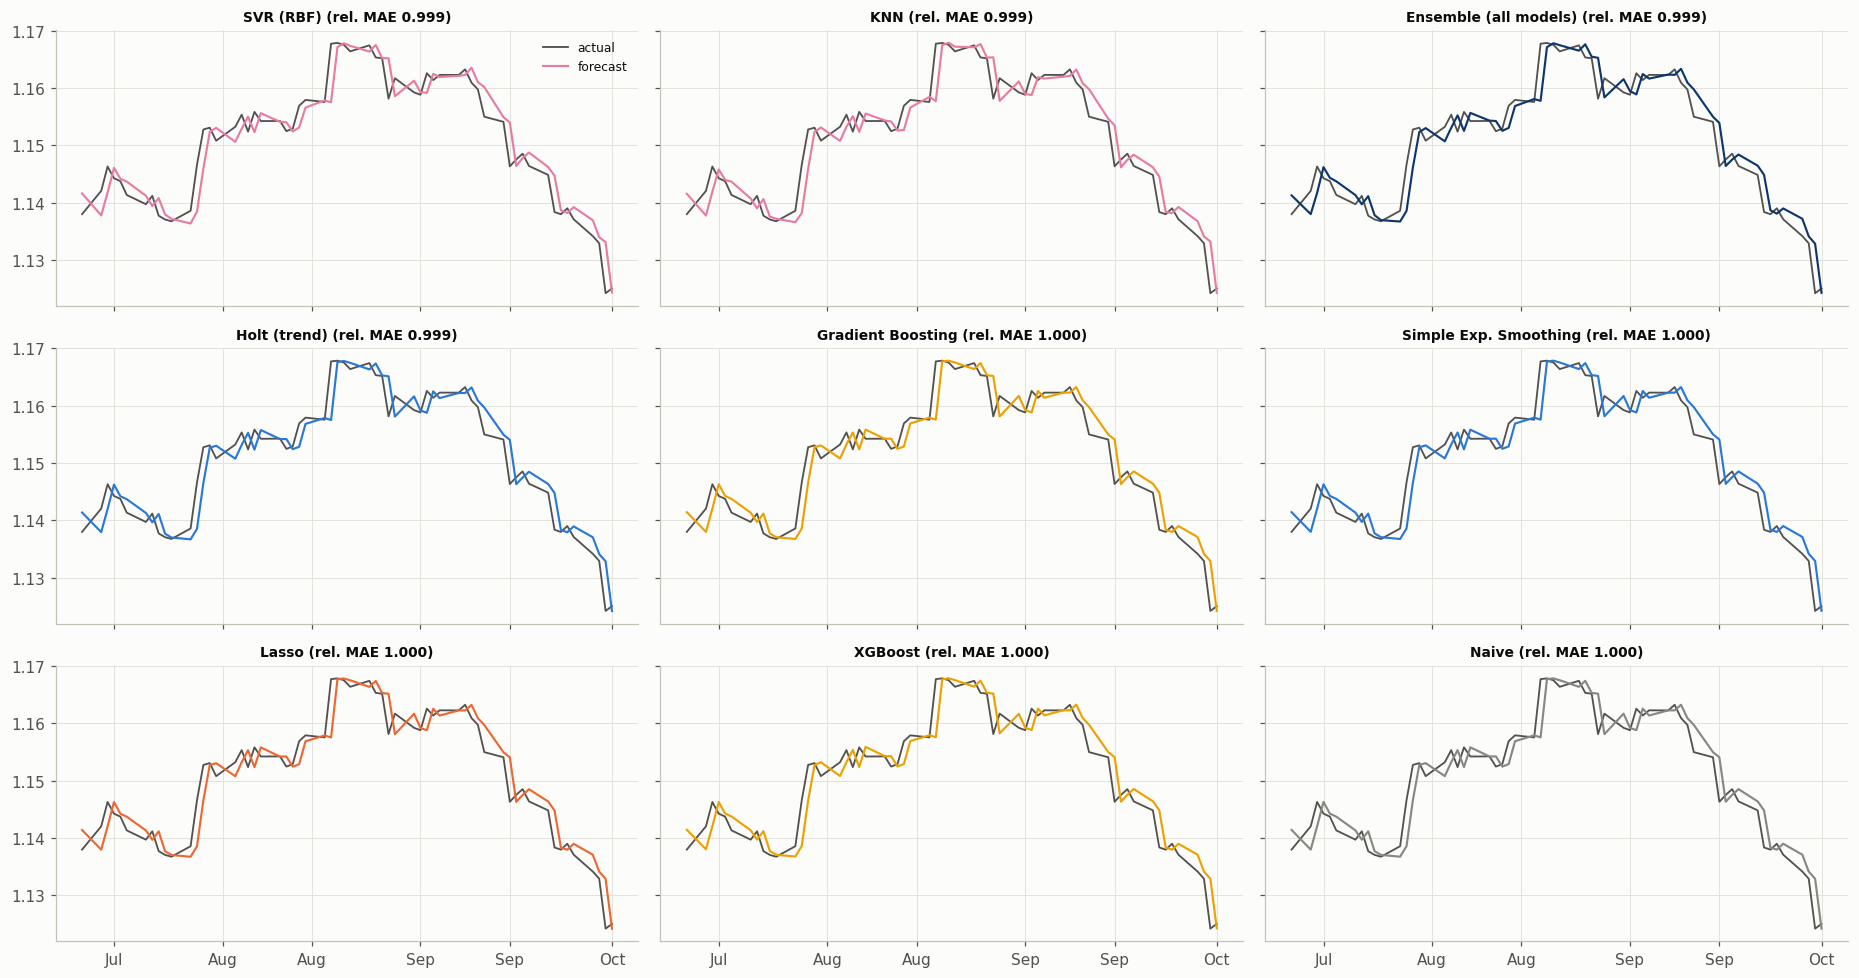

In [13]:
mk = "EUR/USD"; R = OUT[mk]["res"]; P = OUT[mk]["pred"]; te = SPLIT[mk]["te"]
names = list(R.index[:8]) + (["Naive"] if "Naive" not in R.index[:8] else [])
fig, axes = plt.subplots(3, 3, figsize=(17, 9), sharex=True, sharey=True); axes = axes.ravel()
lastd = te.index[-60:]
for ax, n in zip(axes, names):
    ax.plot(lastd, te["next_close"].loc[lastd].values, color=INK2, lw=1.2, label="actual")
    ax.plot(lastd, pd.Series(P[n], index=te.index).loc[lastd].values, color=FAM_COL[OUT[mk]["fam"][n]], lw=1.4, label="forecast")
    ax.set_title(f"{n} (rel. MAE {R.loc[n, 'Relative MAE']:.3f})", fontsize=9); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

### 10.3 Stability across years
Relative MAE computed separately for each test year (below 1 = more accurate than the naive forecast that year).

In [14]:
mk = "EUR/USD"; R = OUT[mk]["res"]; P = OUT[mk]["pred"]; te = SPLIT[mk]["te"]
naive_err = pd.Series(np.abs(te["next_close"].values - te["close"].values), index=te.index).groupby(te.index.year).mean()
Y = pd.DataFrame({n: pd.Series(np.abs(te["next_close"].values - P[n]), index=te.index).groupby(te.index.year).mean() / naive_err for n in R.index}).T
Y["years below 1"] = (Y < 1).sum(axis=1)
display(Y.style.format("{:.4f}").format({"years below 1": "{:.0f}"}).background_gradient(cmap="RdYlGn_r", vmin=0.97, vmax=1.06, subset=Y.columns[:-1]))

time,2023,2024,2025,2026,years below 1
SVR (RBF),0.999673,1.002251,0.995765,0.997830,3
KNN,0.995205,0.997595,1.010092,0.987508,3
Ensemble (all models),0.999402,0.995571,1.000328,1.000983,2
Holt (trend),0.999943,0.999158,0.999895,0.997750,4
Gradient Boosting,1.000190,0.998514,0.999868,0.999806,3
Simple Exp. Smoothing,0.999699,0.999785,0.999830,0.999812,4
Lasso,1.000035,0.999792,1.000010,0.999472,2
XGBoost,0.999774,0.999186,1.000835,0.999292,3
ARIMA,1.000000,1.000000,1.000000,1.000000,0
Naive,1.000000,1.000000,1.000000,1.000000,0


**Explanation (EUR/USD).**
* **Holt** and **Simple Exponential Smoothing** are below 1 in all 4 test years, with very small margins (at most 0.2 %).
* SVR, KNN, Gradient Boosting, XGBoost, MLP and TFT are below 1 in 3 of the 4 years.
* BiTCN, TiDE, TCN, N-HiTS, N-BEATS, H2O AutoML and LightGBM are above 1 **every year**.

## 11. Results: S&P 500
### 11.1 Test-set metrics
MAE and RMSE are expressed in **index points**.

In [15]:
mk = "S&P 500"; R = OUT[mk]["res"]; info = OUT[mk]["info"]
print(f"ARIMA order selected by AIC: {info['arima_order']} | SES alpha = {info['ses_alpha']:.3f} | Holt alpha, beta = {info['holt'][0]:.3f}, {info['holt'][1]:.3f} | H2O leader: {info['h2o_leader']}")
print("Hyperparameters selected on the validation set:"); print({k: v for k, v in info["best_params"].items()})
display(R.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "MAPE %": "{:.3f}", "R2": "{:.4f}", "Relative MAE": "{:.4f}", "DM p-value": "{:.3f}",
                        "DM p (Holm)": "{:.3f}", "Rel. MAE std (5 seeds)": "{:.4f}", "Training time (s)": "{:.1f}"}, na_rep="-")
        .background_gradient(subset=["Relative MAE"], cmap="RdYlGn_r", vmin=0.98, vmax=1.05))

ARIMA order selected by AIC: (2, 1, 2) | SES alpha = 0.899 | Holt alpha, beta = 0.898, 0.000 | H2O leader: DeepLearning_1_AutoML_1_20261005_15953
Hyperparameters selected on the validation set:
{'Linear Regression': {}, 'Ridge': {'alpha': 1}, 'Lasso': {'alpha': 0.05}, 'KNN': {'k': 50}, 'SVR (RBF)': {'C': 0.1}, 'Decision Tree': {'depth': 2}, 'Random Forest': {'depth': 4, 'leaf': 100}, 'Extra Trees': {'depth': 8, 'leaf': 100}, 'Gradient Boosting': {'n': 100, 'depth': 2}, 'XGBoost': {'n': 100, 'depth': 2}, 'LightGBM': {'n': 100, 'leaves': 7}, 'CatBoost': {'n': 200, 'depth': 6}, 'MLP': {'h': (64, 32), 'alpha': 0.01}, 'LSTM': {'hidden': 64, 'lr': 0.0003}, 'GRU': {'hidden': 64, 'lr': 0.0003}, '1D CNN': {'hidden': 64, 'lr': 0.001}, 'Transformer': {'hidden': 64, 'lr': 0.001}, 'N-BEATS': {'input_size': 60, 'learning_rate': 0.001}, 'N-HiTS': {'input_size': 15, 'learning_rate': 0.0003}, 'TiDE': {'input_size': 15, 'learning_rate': 0.001}, 'DLinear': {'input_size': 60, 'learning_rate': 0.001}, 'Dee

,Family,Rank,MAE,RMSE,MAPE %,R2,Relative MAE,DM p-value,Rel. MAE std (5 seeds),Training time (s),DM p (Holm),Significant (Holm 5%)
TFT,Deep forecasting,1,36.47,51.65,0.649,0.9978,0.9930,0.398,0.0021,63.7,1.000,False
1D CNN,Neural networks,2,36.50,51.88,0.649,0.9978,0.9940,0.125,0.0006,2.7,1.000,False
SVR (RBF),Distance / kernel,3,36.51,51.87,0.649,0.9978,0.9943,0.397,-,1.1,1.000,False
Ensemble (deep learning),Ensembles,4,36.52,51.54,0.650,0.9979,0.9945,0.197,-,231.8,1.000,False
XGBoost,Boosting,5,36.60,51.76,0.651,0.9978,0.9966,0.066,-,0.1,1.000,False
Gradient Boosting,Boosting,6,36.61,51.77,0.651,0.9978,0.9968,0.101,-,1.5,1.000,False
Ensemble (all models),Ensembles,7,36.62,51.63,0.652,0.9978,0.9973,0.143,-,363.8,1.000,False
PatchTST,Deep forecasting,8,36.64,52.00,0.652,0.9978,0.9978,0.725,0.0033,18.9,1.000,False
DeepAR,Deep forecasting,9,36.66,52.10,0.653,0.9978,0.9982,0.600,0.0024,44.4,1.000,False
Decision Tree,Trees,10,36.71,51.62,0.653,0.9978,0.9996,0.282,-,0.0,1.000,False


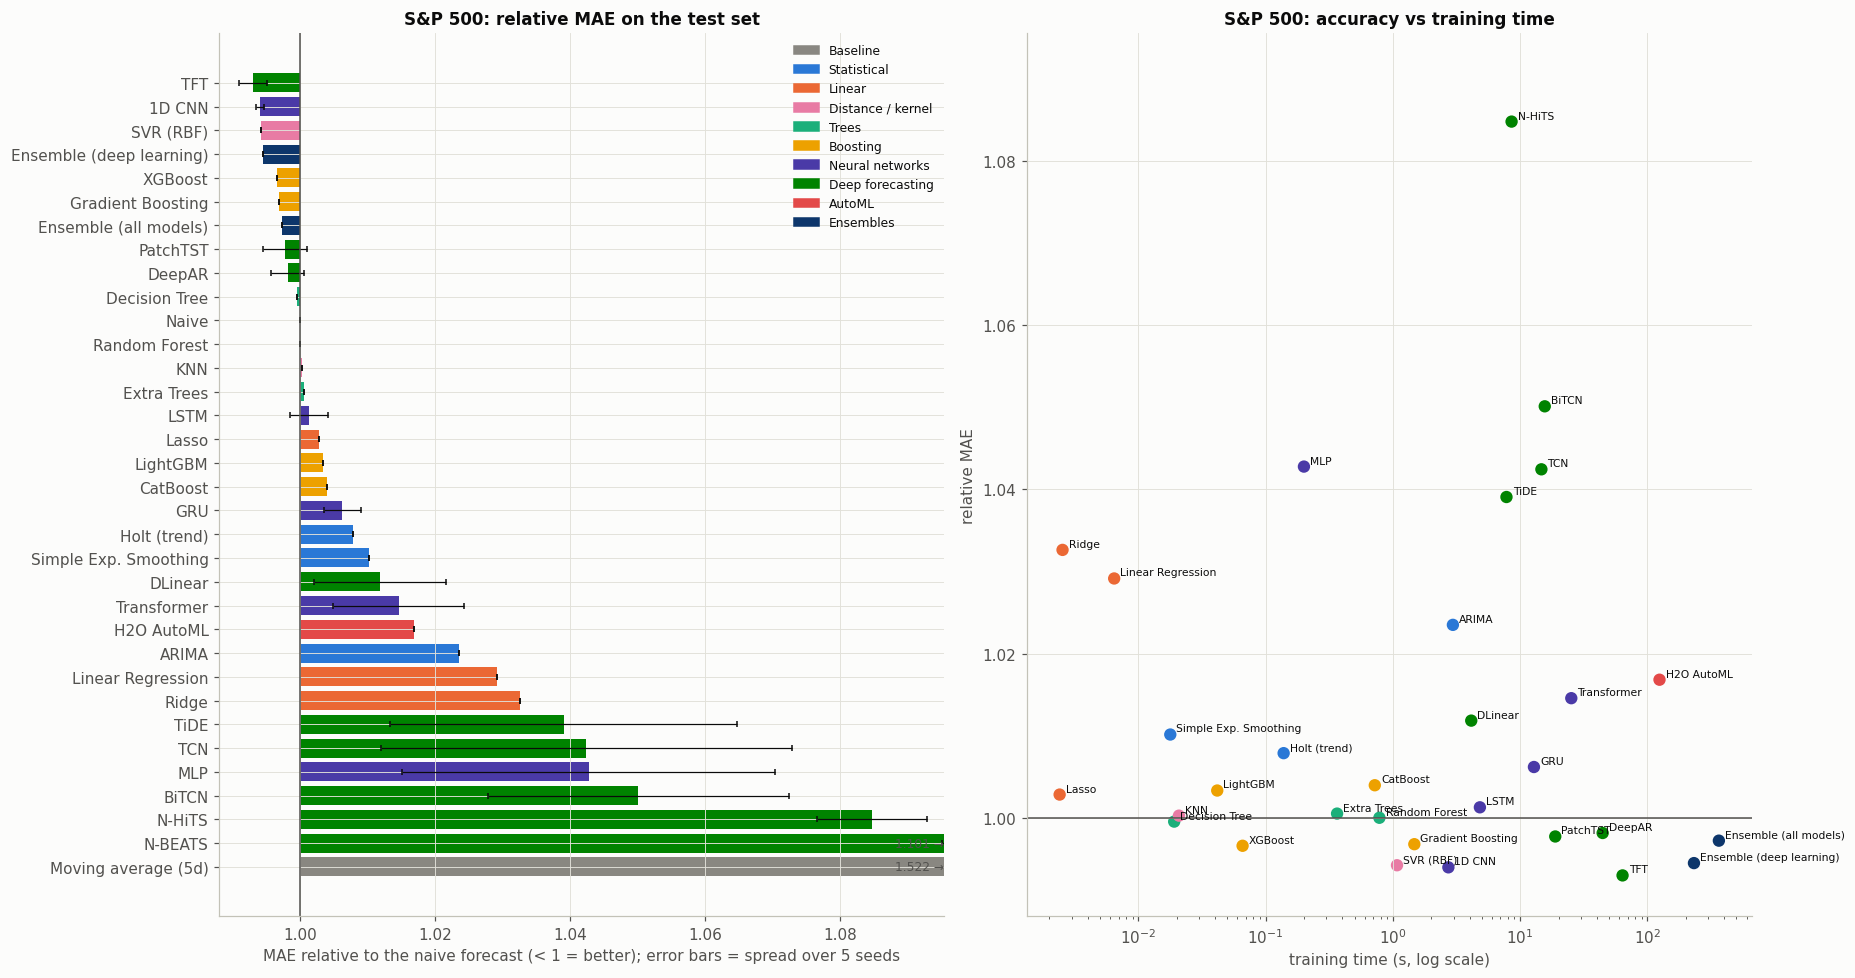

In [16]:
mk = "S&P 500"; R = OUT[mk]["res"]
fig, ax = plt.subplots(1, 2, figsize=(17, 9))
r = R.sort_values("Relative MAE", ascending=False)
ax[0].barh(r.index, r["Relative MAE"] - 1, left=1, color=[FAM_COL[f] for f in r.Family], xerr=r["Rel. MAE std (5 seeds)"].fillna(0).values,
           error_kw=dict(ecolor=INK, lw=0.8, capsize=2)); ax[0].axvline(1, color=INK2, lw=1)
lo, hi = max(0.95, r["Relative MAE"].min() - 0.005), min(1.10, max(1.01, r["Relative MAE"].quantile(0.95) + 0.005)); ax[0].set_xlim(lo, hi)
for i, v in enumerate(r["Relative MAE"]):
    if v > hi: ax[0].text(hi, i, f"{v:.3f} →", va="center", ha="right", fontsize=8, color=INK2)
ax[0].set_xlabel("MAE relative to the naive forecast (< 1 = better); error bars = spread over 5 seeds"); ax[0].set_title(f"{mk}: relative MAE on the test set")
ax[0].legend(handles=[Patch(color=c, label=f) for f, c in FAM_COL.items()], loc="upper right", fontsize=8)
t = R[R["Training time (s)"] > 0]
ax[1].scatter(t["Training time (s)"], t["Relative MAE"], s=50, color=[FAM_COL[f] for f in t.Family])
for n, row in t.iterrows(): ax[1].annotate(n, (row["Training time (s)"], row["Relative MAE"]), fontsize=7, xytext=(4, 2), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].axhline(1, color=INK2, lw=1); ax[1].set_ylim(lo, hi)
ax[1].set_xlabel("training time (s, log scale)"); ax[1].set_ylabel("relative MAE"); ax[1].set_title(f"{mk}: accuracy vs training time")
plt.tight_layout(); plt.show()

### Explanation of the S&P 500 results
**Overall.** On the 940 test days (2023 to October 2026), the naive forecast has an MAE of **36.72 index points**
(MAPE 0.65 %). **10 algorithms** have a relative MAE below 1, the best by **0.7 %**. **No algorithm is significantly
better than the naive forecast**: the smallest Diebold–Mariano p-value among the improving models is 0.066 (XGBoost),
and after the Holm correction all of them are equal to 1. Only N-BEATS (and the moving average) is significantly
**worse** than naive after the correction.

| Rank | Algorithm | Relative MAE | Explanation |
|---|---|---|---|
| 1 | **TFT** | 0.9930 (± 0.0021) | best model on average over 5 seeds; a 60-day input window was selected on validation |
| 2 | **1D CNN** | 0.9940 (± 0.0006) | very stable across seeds (smallest spread of all neural networks) |
| 3 | **SVR (RBF)** | 0.9943 | C = 0.1 selected, less regularised than on EUR/USD |
| 4 | **Ensemble (deep learning)** | 0.9945 | average of the 14 neural forecasts |
| 5-7 | XGBoost, Gradient Boosting, Ensemble (all models) | 0.9966-0.9973 | small improvements |
| 8-10 | PatchTST, DeepAR, Decision Tree | 0.9978-0.9996 | marginal improvements |
| 11-12 | Naive, Random Forest | 1.0000 | reference level |
| 13-21 | KNN, Extra Trees, LSTM, Lasso, LightGBM, CatBoost, GRU, Holt, SES | 1.0003-1.0102 | Holt and SES select α ≈ 0.90: they smooth the last prices instead of repeating the last one, which adds error |
| 22-24 | DLinear, Transformer, H2O AutoML | 1.012-1.017 | the H2O leader is a deep learning model |
| 25-27 | ARIMA(2,1,2), Linear Regression, Ridge | 1.024-1.033 | AIC selected a richer ARIMA on the training data, and the autocorrelation pattern it captured did not hold in 2023-2026; Ridge selected its weakest penalty (α = 1) |
| 28-33 | TiDE, TCN, MLP, BiTCN, N-HiTS, N-BEATS | 1.039-1.101 | N-BEATS is significantly worse after correction |
| 34 | Moving average (5d) | 1.522 | structural lag |

**Hyperparameters.** On the S&P 500, validation selected **less** regularisation than on EUR/USD for several models:
Ridge α = 1 (vs 100), k = 50 for KNN (vs 200), C = 0.1 for SVR (vs 0.01), and a weaker MLP penalty. This is
consistent with the S&P 500 having a measurable short-term autocorrelation, so its features carry slightly more
usable information.

### 11.2 Forecasts of the 8 best algorithms and the naive forecast (last 60 test days)

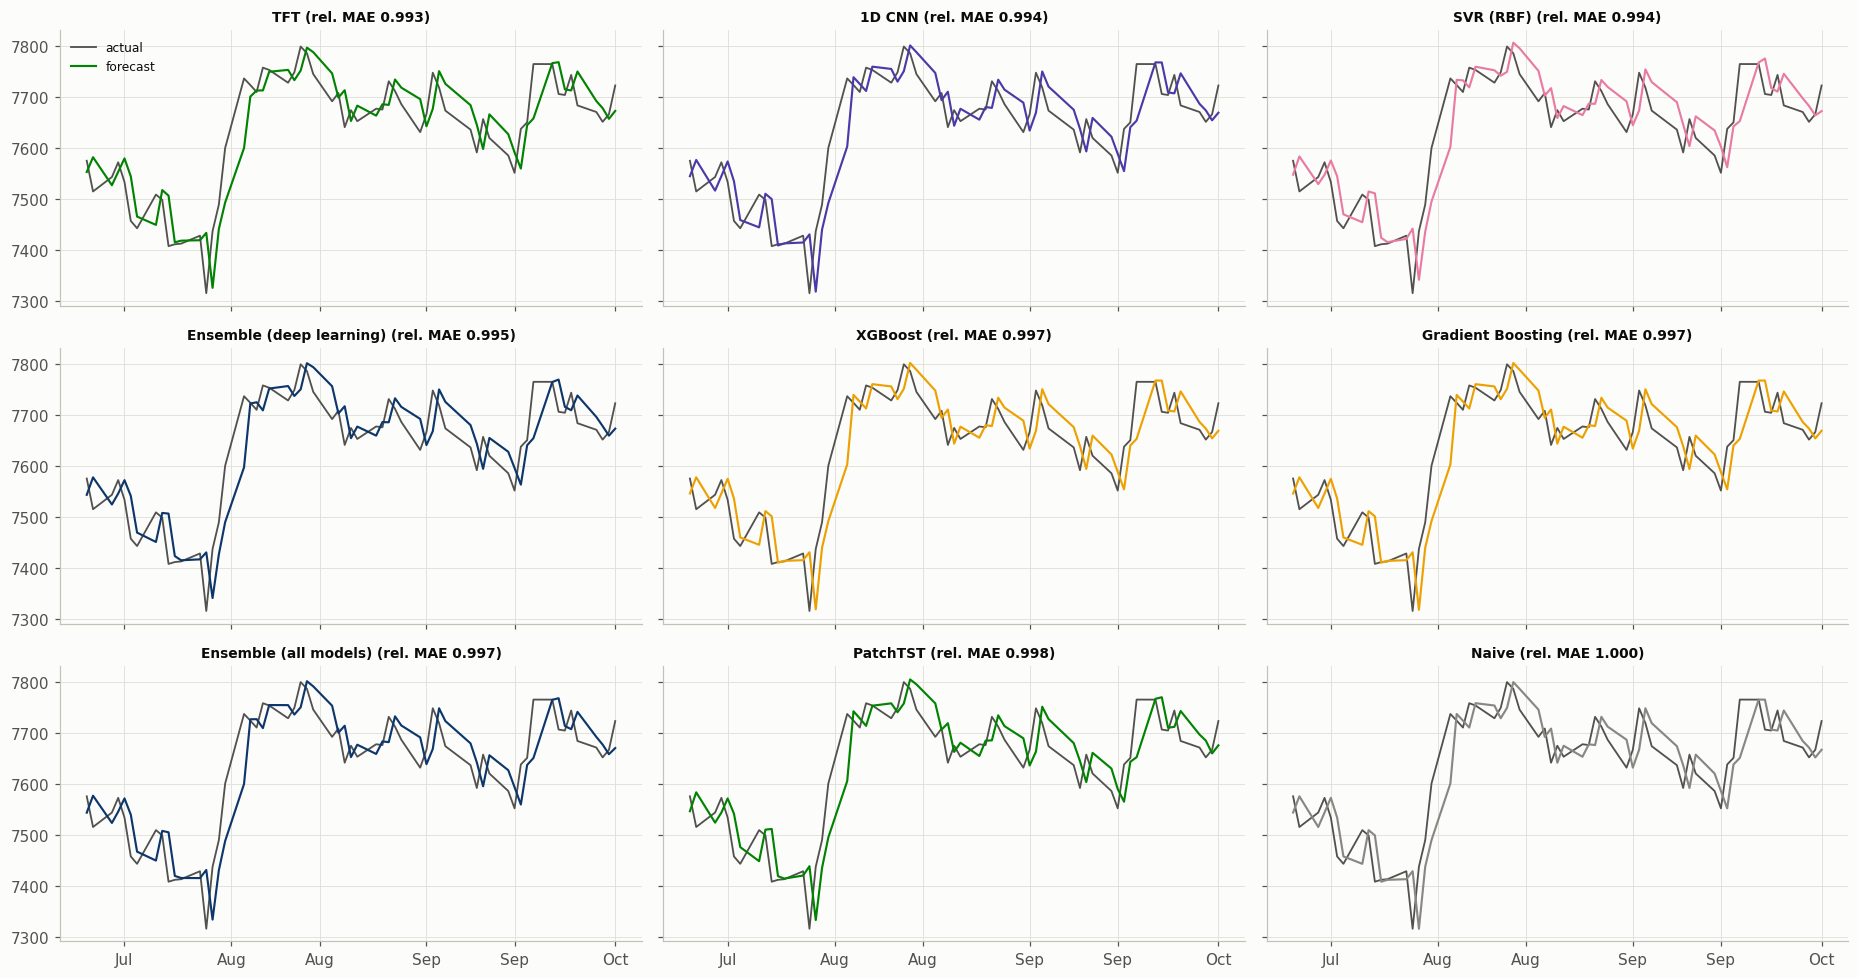

In [17]:
mk = "S&P 500"; R = OUT[mk]["res"]; P = OUT[mk]["pred"]; te = SPLIT[mk]["te"]
names = list(R.index[:8]) + (["Naive"] if "Naive" not in R.index[:8] else [])
fig, axes = plt.subplots(3, 3, figsize=(17, 9), sharex=True, sharey=True); axes = axes.ravel()
lastd = te.index[-60:]
for ax, n in zip(axes, names):
    ax.plot(lastd, te["next_close"].loc[lastd].values, color=INK2, lw=1.2, label="actual")
    ax.plot(lastd, pd.Series(P[n], index=te.index).loc[lastd].values, color=FAM_COL[OUT[mk]["fam"][n]], lw=1.4, label="forecast")
    ax.set_title(f"{n} (rel. MAE {R.loc[n, 'Relative MAE']:.3f})", fontsize=9); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

### 11.3 Stability across years
Relative MAE computed separately for each test year (below 1 = more accurate than the naive forecast that year).

In [18]:
mk = "S&P 500"; R = OUT[mk]["res"]; P = OUT[mk]["pred"]; te = SPLIT[mk]["te"]
naive_err = pd.Series(np.abs(te["next_close"].values - te["close"].values), index=te.index).groupby(te.index.year).mean()
Y = pd.DataFrame({n: pd.Series(np.abs(te["next_close"].values - P[n]), index=te.index).groupby(te.index.year).mean() / naive_err for n in R.index}).T
Y["years below 1"] = (Y < 1).sum(axis=1)
display(Y.style.format("{:.4f}").format({"years below 1": "{:.0f}"}).background_gradient(cmap="RdYlGn_r", vmin=0.97, vmax=1.06, subset=Y.columns[:-1]))

Date,2023,2024,2025,2026,years below 1
TFT,1.001895,0.978276,0.984617,0.999459,3
1D CNN,0.993332,0.994628,0.992293,0.994297,4
SVR (RBF),1.005371,0.981915,0.977959,1.018053,2
Ensemble (deep learning),1.011804,0.985332,0.982898,1.004340,2
XGBoost,0.995892,0.994400,0.996867,0.999026,4
Gradient Boosting,0.996267,0.993979,0.996568,1.000286,3
Ensemble (all models),1.005582,0.992844,0.990541,1.003396,2
PatchTST,1.003946,0.985493,0.986216,1.007812,2
DeepAR,1.005562,0.983280,0.986469,1.000483,2
Decision Tree,0.996213,1.001372,1.006803,0.991232,2


**Explanation (S&P 500).**
* **1D CNN** and **XGBoost** are below 1 in all 4 test years.
* TFT, Gradient Boosting and Random Forest are below 1 in 3 years. TFT has its largest gains in 2024 (−2.2 %) and 2025
  (−1.5 %), and it is close to 1 in 2023 and 2026.
* GRU, Holt, SES, the Transformer, ARIMA, Linear Regression, Ridge, MLP, TiDE, TCN, BiTCN, N-HiTS, N-BEATS and the
  moving average are above 1 **every year**.

## 12. EUR/USD vs S&P 500 comparison

,EUR/USD,S&P 500,Family,Rank EUR/USD,Rank S&P 500
TFT,1.0081,0.9930,Deep forecasting,27,1
1D CNN,1.0010,0.9940,Neural networks,16,2
SVR (RBF),0.9987,0.9943,Distance / kernel,1,3
Ensemble (deep learning),1.0001,0.9945,Ensembles,12,4
XGBoost,0.9999,0.9966,Boosting,8,5
Gradient Boosting,0.9996,0.9968,Boosting,5,6
Ensemble (all models),0.9991,0.9973,Ensembles,3,7
PatchTST,1.0061,0.9978,Deep forecasting,26,8
DeepAR,1.0031,0.9982,Deep forecasting,21,9
Decision Tree,1.0000,0.9996,Trees,11,10


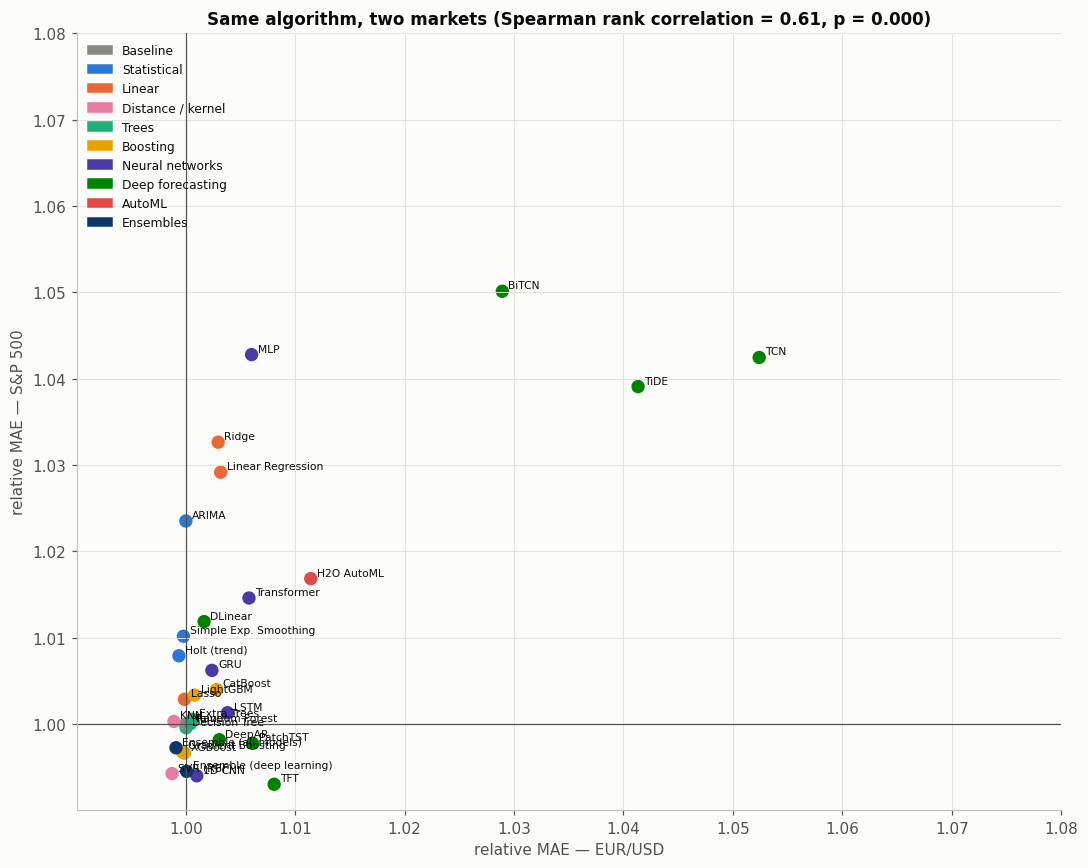

In [19]:
C = pd.DataFrame({mk: OUT[mk]["res"]["Relative MAE"] for mk in MARKETS})
C["Family"] = OUT["EUR/USD"]["res"]["Family"].reindex(C.index)
C["Rank EUR/USD"] = C["EUR/USD"].rank().astype(int); C["Rank S&P 500"] = C["S&P 500"].rank().astype(int)
C = C.sort_values("S&P 500")
display(C.style.format({"EUR/USD": "{:.4f}", "S&P 500": "{:.4f}"}).background_gradient(subset=["EUR/USD", "S&P 500"], cmap="RdYlGn_r", vmin=0.97, vmax=1.06))
rho, p = stats.spearmanr(C["EUR/USD"], C["S&P 500"])
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(C["EUR/USD"], C["S&P 500"], s=60, color=[FAM_COL[f] for f in C.Family])
for n, row in C.iterrows(): ax.annotate(n, (row["EUR/USD"], row["S&P 500"]), fontsize=7, xytext=(4, 2), textcoords="offset points")
lim = (min(C["EUR/USD"].min(), C["S&P 500"].min()) - 0.003, min(1.08, max(C["EUR/USD"].quantile(0.95), C["S&P 500"].quantile(0.95)) + 0.005))
ax.set_xlim(lim); ax.set_ylim(lim); ax.axvline(1, color=INK2, lw=.8); ax.axhline(1, color=INK2, lw=.8)
ax.set_xlabel("relative MAE — EUR/USD"); ax.set_ylabel("relative MAE — S&P 500")
ax.set_title(f"Same algorithm, two markets (Spearman rank correlation = {rho:.2f}, p = {p:.3f})")
ax.legend(handles=[Patch(color=c, label=f) for f, c in FAM_COL.items()], fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

**Explanation.**
* The **Spearman rank correlation** between the two markets is **0.61** (p < 0.001): an algorithm that ranks well on
  one market tends to rank well on the other.
* **Consistent results on both markets**:
  * **SVR** is in the top 3 on both markets.
  * **Gradient Boosting** and **XGBoost** are in the top 8 on both.
  * **N-HiTS** and **N-BEATS** are ranks 32-33 on both, and TiDE, TCN and BiTCN are also in the bottom group on both.
* **Results that depend on the market**:
  * **TFT**: rank 27 on EUR/USD, rank 1 on the S&P 500.
  * **1D CNN**: rank 16 vs rank 2.
  * **PatchTST**: rank 26 vs rank 8.
  * **KNN**: rank 2 vs rank 13.
  * **Holt** and **SES**: ranks 4 and 6 on EUR/USD, ranks 20 and 21 on the S&P 500.
  * **ARIMA**: rank 9 vs rank 25. AIC chose the random walk (0,1,0) on EUR/USD and the richer (2,1,2) on the S&P 500.
* **Size of the improvements**: on EUR/USD the best algorithm improves on the naive forecast by 0.13 %, on the S&P 500
  by 0.7 %. On neither market is any improvement statistically significant after the Holm correction.

## 13. Summary

| Step | What was done | Result |
|---|---|---|
| Data collection | EUR/USD from MetaTrader 5, S&P 500 from Yahoo Finance, both 2005-2026 | 5 646 and 5 472 daily bars |
| Cleaning | 8 quality checks per market | no invalid rows; extreme S&P 500 crash days kept |
| Exploratory analysis | statistics, stationarity, autocorrelation | prices non-stationary, daily changes stationary; S&P 500 twice as volatile, much fatter tails, lag-1 autocorrelation −0.12 |
| Feature engineering | 29 features in percent terms | identical definitions for both markets |
| Tuning | every family tuned on 2020-2022 (grids, ARIMA order by AIC, network size, input window, learning rate) | single evaluation on 2023-2026 |
| Robustness | 5 random seeds for the 14 neural networks; Holm correction for 33 simultaneous tests | seed spreads reported; significance corrected |

**Results**

| | EUR/USD | S&P 500 |
|---|---|---|
| Naive forecast MAE | 35.92 pips | 36.72 points |
| Best algorithm | SVR (RBF), relative MAE 0.9987 | TFT, relative MAE 0.9930 (± 0.0021 over seeds) |
| Algorithms with relative MAE below 1 | 8 of 33 | 10 of 33 |
| Significantly better than naive (Holm-corrected) | none | none |
| Significantly worse than naive (Holm-corrected) | TiDE, TCN, N-HiTS, N-BEATS | N-BEATS |
| Below 1 in all 4 test years | Holt, SES | 1D CNN, XGBoost |
| Rank correlation between markets | 0.61 | |

**Main findings**
1. On both markets, the best algorithms improve on the naive forecast by less than 1 %, and no improvement is
   statistically significant once the number of algorithms tested is taken into account.
2. The S&P 500 offers more room for improvement (0.7 % vs 0.13 %), consistent with its short-term autocorrelation,
   and validation selects less regularised models on it.
3. Random seeds matter: for the neural networks, the spread over 5 seeds is often as large as the gap between
   neighbouring algorithms in the ranking.
4. Tuning the deep forecasting models on validation improved several of them (TFT becomes the best model on the S&P
   500), but N-BEATS and N-HiTS remain the least accurate trained models on both markets.

**Reusing the notebook.** Add or replace markets in the `MARKETS` dictionary (MetaTrader 5 symbol, Yahoo Finance
ticker, start date, price unit, optional fixed source) and run all cells.